# HybridMixtureNetwork â€” Intraday 30min + Classification + Optuna

Single TCN + MDN with VAE regime autoencoder and MLP head,
adapted for **intraday 30-min** natural gas bars.

Pipeline:
1. Load raw tick/bar CSV via `read_exported_df`
2. Resample to configurable bar size (default 30min)
3. `ContinuousIntradayPrep` for session-aware technical features
4. Forward-fill daily EIA storage + weather onto intraday bars
5. Build regime features from daily aggregation (causal)
6. Windowed dataset â†’ HybridMixtureNetwork with optional classification + VSN

In [3]:
from dotenv import load_dotenv; load_dotenv('/workspace/model_data/dot.env')

import os
import sys
import copy
import math
import time as _time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

try:
    import optuna
    from optuna.pruners import MedianPruner
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    _OPTUNA = True
except ImportError:
    print('optuna not installed -- pip install optuna')
    _OPTUNA = False

warnings.filterwarnings('ignore')

print(f'PyTorch : {torch.__version__}')
print(f'Optuna  : {optuna.__version__ if _OPTUNA else "N/A"}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.4.1+cu124
Optuna  : 4.8.0
CUDA    : True
GPU     : NVIDIA A40


In [4]:
from CTAFlow.models.deep_learning.multi_branch.ng_moe import (
    HybridConfig,
    HybridMixtureNetwork,
    HybridLoss,
)
from CTAFlow.data.raw_formatting.intraday_manager import read_exported_df
from CTAFlow.models.prep.intraday_continuous import (
    ContinuousIntradayPrep,
    SessionSpec,
)

# macrOS-Int for EIA + weather
sys.path.insert(0, r'C:\Users\nicho\PycharmProjects\macrOS-Int')
from MacrOSINT.data.sources.eia.api_tools import NatGasHelper
from MacrOSINT.models.energy.natgas_storage_forecast import (
    NatGasStorageForecaster,
    fetch_storage_data,
    ConsensusForecast,
    compute_degree_days,
    compute_spline_hdd_basis,
)

# Device
def _select_device():
    if not torch.cuda.is_available():
        return 'cpu'
    try:
        t = torch.zeros(1, device='cuda')
        _ = t + 1
        return 'cuda'
    except RuntimeError as e:
        print(f'CUDA unusable ({e}) -- CPU fallback')
        return 'cpu'

DEVICE = _select_device()
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration

In [5]:
# --- Paths ---
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    SAVE_DIR    = Path('/content/drive/MyDrive/results/ng_hybrid_intraday')
    DATA_DIR    = Path('/content/drive/MyDrive/features')
else:
    SAVE_DIR    = Path('/workspace/results/ng_hybrid_intraday')
    DATA_DIR    = Path('/workspace/model_data')

SAVE_DIR.mkdir(parents=True, exist_ok=True)

INTRADAY_CSV = DATA_DIR / 'NG' / 'intraday_2.csv'
EIA_HDF      = str(DATA_DIR / 'new_ng_eia_cache.hdf')
WEATHER_HDF  = str(DATA_DIR / 'new_weather.hdf')

# --- Intraday config ---
BAR_MINUTES       = 15          # resample frequency
SESSION           = SessionSpec('USA', '02:30', '15:00')  # configurable session
TARGET_HORIZON_BARS = 10         # forecast horizon in bars (2 * 30min = 60min)
SEQ_LEN           = 20          # lookback window in bars
AE_WINDOW_DAYS    = 10          # regime encoder lookback in trading days

# --- Classification config ---
N_CLASSES = 4                   # quartile-based: <25 / <50 / >50 / >75
USE_POSITIONING = True          # tanh exposure head
USE_VSN = True                  # grouped variable selection
MONDAY_ONLY = False             # sample every bar, not just Mondays

# --- Optuna ---
N_TRIALS       = 40
MAX_EPOCHS_OPT = 80
OPT_PATIENCE   = 10

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Save dir     : {SAVE_DIR}')
print(f'Intraday CSV : {INTRADAY_CSV}')
print(f'Bar freq     : {BAR_MINUTES}min')
print(f'Session      : {SESSION.name} ({SESSION.start}-{SESSION.end})')
print(f'Target       : {TARGET_HORIZON_BARS} bars = {TARGET_HORIZON_BARS * BAR_MINUTES}min')
print(f'Seq len      : {SEQ_LEN} bars')
print(f'Classes      : {N_CLASSES}')
print(f'Positioning  : {USE_POSITIONING}')
print(f'VSN          : {USE_VSN}')

Save dir     : /workspace/results/ng_hybrid_intraday
Intraday CSV : /workspace/model_data/NG/intraday_2.csv
Bar freq     : 15min
Session      : USA (02:30-15:00)
Target       : 10 bars = 150min
Seq len      : 20 bars
Classes      : 4
Positioning  : True
VSN          : True


## 2. Load & Resample Intraday Data

In [6]:
# Load raw Sierra Chart CSV
raw_df = read_exported_df(str(INTRADAY_CSV))
print(f'Raw bars     : {raw_df.shape}')
print(f'Date range   : {raw_df.index[0]} to {raw_df.index[-1]}')
print(f'Columns      : {raw_df.columns.tolist()}')

# Standardize column names
raw_df.columns = [c.lower() for c in raw_df.columns]
for old, new in [('last', 'close'), ('vol', 'volume'), ('numberoftrades', 'ticks')]:
    if old in raw_df.columns and new not in raw_df.columns:
        raw_df.rename(columns={old: new}, inplace=True)

# Resample to BAR_MINUTES
resample_rule = f'{BAR_MINUTES}min'
ohlcv_agg = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
}
if 'volume' in raw_df.columns:
    ohlcv_agg['volume'] = 'sum'
if 'ticks' in raw_df.columns:
    ohlcv_agg['ticks'] = 'sum'

df = raw_df.resample(resample_rule).agg(ohlcv_agg).dropna(subset=['close'])

# Filter to session hours
session_start = pd.Timestamp(SESSION.start).time()
session_end = pd.Timestamp(SESSION.end).time()
df = df.between_time(session_start, session_end)

print(f'\nResampled    : {df.shape} @ {resample_rule}')
print(f'Session      : {SESSION.start}-{SESSION.end}')
print(f'Date range   : {df.index[0]} to {df.index[-1]}')
print(f'Bars/day     : ~{df.groupby(df.index.date).size().median():.0f}')
df.tail(5)

Raw bars     : (944483, 13)
Date range   : 2012-07-16 17:00:00 to 2026-03-25 19:00:00
Columns      : ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume', '#ofTrades', 'OHLCAvg', 'HLCAvg', 'HLAvg', 'BidVolume', 'AskVolume']

Resampled    : (178927, 5) @ 15min
Session      : 02:30-15:00
Date range   : 2012-07-17 02:30:00 to 2026-03-25 15:00:00
Bars/day     : ~51


,open,high,low,close,volume
Datetime,,,,,
2026-03-25 14:00:00,2.928,2.932,2.922,2.922,624
2026-03-25 14:15:00,2.922,2.927,2.921,2.924,522
2026-03-25 14:30:00,2.924,2.930,2.920,2.930,800
2026-03-25 14:45:00,2.929,2.929,2.922,2.926,453
2026-03-25 15:00:00,2.926,2.938,2.926,2.935,436


## 3. Load EIA Storage + Consensus

In [ ]:
# === Fetch fresh EIA storage data (always from API, then cache) ===
START = df.index[0].strftime('%Y-%m')
END   = df.index[-1].strftime('%Y-%m')

ng_helper    = NatGasHelper()
storage_wkly = fetch_storage_data(ng_helper, start=START, end=END)
NatGasStorageForecaster.save_eia_cache(storage=storage_wkly, hdf_path=EIA_HDF)
print(f'EIA storage from API : {storage_wkly.shape} ({storage_wkly.index[0].date()} to {storage_wkly.index[-1].date()})')

# Consensus forecast for surprise features
try:
    cf = ConsensusForecast()
    cf.fit(storage_wkly['storage_change'])
    surprise_df = cf.transform()
    storage_wkly = storage_wkly.join(
        surprise_df[['consensus_est', 'surprise']], how='left'
    )
    print(f'ConsensusForecast added')
except Exception as e:
    print(f'ConsensusForecast failed ({e}) -- using rolling 4-week proxy')
    chg = storage_wkly['storage_change']
    storage_wkly['consensus_est'] = chg.rolling(4).mean()
    storage_wkly['surprise']      = chg - storage_wkly['consensus_est']

print(f'Weekly columns: {storage_wkly.columns.tolist()}')

## 4. Load Weather

HDD/CDD degree-day features forward-filled onto intraday bars.

In [ ]:
# === Load or regenerate weather data (full history, epoch-aware) ===
# PopulationWeatherGrid uses census-epoch grids (2020, 2024) for population weighting.
# _fetch_weather_by_epoch splits the date range across epochs automatically.

daily_weather = NatGasStorageForecaster.load_weather_hdf(hdf_path=WEATHER_HDF)
data_start = df.index[0].normalize()

if daily_weather is not None and not daily_weather.empty:
    weather_start = daily_weather.index[0]
    # Regenerate if cache doesn't cover full intraday history
    if weather_start > data_start + pd.Timedelta(days=30):
        print(f'Weather cache starts {weather_start.date()}, intraday starts {data_start.date()} — regenerating...')
        daily_weather = None
    else:
        daily_weather = daily_weather[
            (daily_weather.index >= data_start) &
            (daily_weather.index <= df.index[-1].normalize())
        ]
        print(f'Weather from cache : {daily_weather.shape} ({daily_weather.index[0].date()} to {daily_weather.index[-1].date()})')

if daily_weather is None or daily_weather.empty:
    print(f'Fetching weather from {data_start.date()} to {df.index[-1].date()} (epoch-aware)...')
    forecaster = NatGasStorageForecaster(
        config_dir=str(SAVE_DIR / 'weather_configs'),
    )
    daily_weather = forecaster._fetch_weather_by_epoch(
        data_start.date(), df.index[-1].date()
    )
    NatGasStorageForecaster.save_weather_hdf(daily_weather, hdf_path=WEATHER_HDF)
    print(f'Weather fetched and cached: {daily_weather.shape} ({daily_weather.index[0].date()} to {daily_weather.index[-1].date()})')

print(f'Columns: {daily_weather.columns.tolist()}')
daily_weather.tail(3)

## 5. Intraday Feature Engineering

Build features using `ContinuousIntradayPrep` then overlay daily storage + weather.

In [9]:
# --- ContinuousIntradayPrep for base technical features ---
prep = ContinuousIntradayPrep(
    sessions=[SESSION],
    bar_minutes=BAR_MINUTES,
)

bars_per_60m = 60 // BAR_MINUTES
steps_60m = TARGET_HORIZON_BARS  # in bars (already at target freq)

df_prep, train_mask, target_cols = prep.prepare(
    df.copy(),
    steps_60m=TARGET_HORIZON_BARS,
    keep_only_active=False,
    add_daily=True,
    add_overnight=True,
    add_deseas=True,
    add_time_features=True,
    add_resample_precalc=False,   # already at 30min, no sub-resample needed
    apply_scaling=False,
    add_bid_ask='bidvol' in df.columns or 'askvol' in df.columns,
    add_event_markers=False,
)

# ContinuousIntradayPrep._standardize_columns uppercases OHLCV (Close, Open, ...);
# downstream cells expect lowercase — normalize here.
df_prep.columns = [c.lower() for c in df_prep.columns]

tech_feature_cols = prep.get_feature_cols(
    steps_60m=TARGET_HORIZON_BARS,
    bar_minutes=BAR_MINUTES,
    add_resample_precalc=False,
    add_bid_ask=False,
    add_event_markers=False,
)
# Match lowered column names
tech_feature_cols = [c.lower() for c in tech_feature_cols]
tech_feature_cols = [c for c in tech_feature_cols if c in df_prep.columns]

print(f'Prepared bars: {df_prep.shape}')
print(f'Tech features: {len(tech_feature_cols)}')
print(f'Target cols  : {target_cols}')

Prepared bars: (178927, 54)
Tech features: 34
Target cols  : ['y_fwd_1', 'y_fwd_2', 'y_fwd_3', 'y_fwd_4', 'y_fwd_5', 'y_fwd_6', 'y_fwd_7', 'y_fwd_8', 'y_fwd_9', 'y_fwd_10']


In [10]:
# === Forward-fill daily storage features onto intraday bars ===
# Use the same approach as NGMoEDataBuilder._add_storage_daily_features
sw = storage_wkly.copy()
sl = sw['storage_level']
sw['sl_4wk_mean'] = sl.rolling(4, min_periods=2).mean()
sw['sl_4wk_max'] = sl.rolling(4, min_periods=2).max()
sw['sl_4wk_min'] = sl.rolling(4, min_periods=2).min()
sw['sl_change_4wk_mean'] = sw['storage_change'].rolling(4, min_periods=2).mean()

storage_cols = ['storage_level', 'storage_change',
                'sl_4wk_mean', 'sl_4wk_max', 'sl_4wk_min', 'sl_change_4wk_mean']
for extra in ['consensus_est', 'surprise']:
    if extra in sw.columns:
        storage_cols.append(extra)

# Create daily index, forward-fill, then reindex to intraday
daily_idx = pd.date_range(sw.index[0], df_prep.index[-1].normalize(), freq='D')
storage_daily = sw[storage_cols].reindex(
    sw.index.union(daily_idx)
).sort_index().ffill()

# Map each intraday bar to its date, then lookup
bar_dates = df_prep.index.normalize()
for col in storage_cols:
    df_prep[col] = storage_daily[col].reindex(bar_dates).values

storage_feature_cols = list(storage_cols)
print(f'Storage features: {len(storage_feature_cols)} -> {storage_feature_cols}')

# === Forward-fill daily weather features onto intraday bars ===
weather_feature_cols = []
if daily_weather is not None and not daily_weather.empty:
    dd = compute_degree_days(daily_weather)

    # HDD/CDD daily + 7-day rolling
    dd['HDD_7d'] = dd['HDD'].rolling(7, min_periods=3).sum()
    dd['CDD_7d'] = dd['CDD'].rolling(7, min_periods=3).sum()
    dd['HDD_7d_chg'] = dd['HDD_7d'] - dd['HDD_7d'].shift(7)
    dd['CDD_7d_chg'] = dd['CDD_7d'] - dd['CDD_7d'].shift(7)

    dd_cols = ['HDD', 'CDD', 'HDD_7d', 'CDD_7d', 'HDD_7d_chg', 'CDD_7d_chg']

    # Spline HDD basis
    try:
        hdd_7d_series = dd['HDD_7d'].fillna(0)
        spline_df, _ = compute_spline_hdd_basis(hdd_7d_series, n_knots=4)
        for sc in spline_df.columns:
            dd[sc] = spline_df[sc].values
            dd_cols.append(sc)
    except Exception:
        pass

    # Population-weighted temperature
    if 'wtd_TAVG' in daily_weather.columns:
        dd['wtd_tavg'] = daily_weather['wtd_TAVG'].values
        dd['wtd_tavg_7d'] = daily_weather['wtd_TAVG'].rolling(7, min_periods=3).mean().values
        dd_cols.extend(['wtd_tavg', 'wtd_tavg_7d'])

    # Forward-fill to intraday
    for col in dd_cols:
        renamed = f'dd_{col.lower()}' if not col.startswith('dd_') else col
        df_prep[renamed] = dd[col].reindex(bar_dates).values
        weather_feature_cols.append(renamed)

    print(f'Weather features: {len(weather_feature_cols)} -> {weather_feature_cols}')
else:
    print('No weather data available')

Storage features: 8 -> ['storage_level', 'storage_change', 'sl_4wk_mean', 'sl_4wk_max', 'sl_4wk_min', 'sl_change_4wk_mean', 'consensus_est', 'surprise']
Weather features: 13 -> ['dd_hdd', 'dd_cdd', 'dd_hdd_7d', 'dd_cdd_7d', 'dd_hdd_7d_chg', 'dd_cdd_7d_chg', 'dd_hdd_sp0', 'dd_hdd_sp1', 'dd_hdd_sp2', 'dd_hdd_sp3', 'dd_hdd_sp4', 'dd_wtd_tavg', 'dd_wtd_tavg_7d']


In [11]:
# === Build daily regime features (12-dim VAE input) ===
# Aggregate intraday bars to daily, then compute regime features

daily_close = df_prep.groupby(df_prep.index.date)['close'].last()
daily_close.index = pd.DatetimeIndex(daily_close.index)
daily_log_ret = np.log(daily_close / daily_close.shift(1))

REGIME_COLS = [
    'regime_ret_1d', 'regime_ret_5d', 'regime_ret_21d',
    'regime_rv_5d', 'regime_rv_21d',
    'regime_pct_in_5y_band', 'regime_dev_5y_zscore', 'regime_band_width_pct',
    'regime_fc_vs_seasonal_z', 'regime_chg_vs_seasonal_z',
    'regime_is_injection', 'regime_dev_x_season',
]

# Returns & vol context (5 features)
regime_daily = pd.DataFrame(index=daily_close.index)
regime_daily['regime_ret_1d'] = daily_log_ret
regime_daily['regime_ret_5d'] = daily_log_ret.rolling(5).sum()
regime_daily['regime_ret_21d'] = daily_log_ret.rolling(21).sum()
regime_daily['regime_rv_5d'] = np.sqrt((daily_log_ret**2).rolling(5).mean()) * np.sqrt(252)
regime_daily['regime_rv_21d'] = np.sqrt((daily_log_ret**2).rolling(21).mean()) * np.sqrt(252)

# Storage state (3 features) -- 5-year band per ISO week (causal)
sl = storage_wkly['storage_level']
wk_idx = sl.index.isocalendar().week.values
hi_5y = pd.Series(np.nan, index=sl.index)
lo_5y = pd.Series(np.nan, index=sl.index)
mean_5y = pd.Series(np.nan, index=sl.index)

for w in range(1, 54):
    mask = wk_idx == w
    if mask.sum() < 2:
        continue
    idx_pos = np.where(mask)[0]
    vals = sl.iloc[idx_pos]
    hi_5y.iloc[idx_pos] = vals.expanding().max().shift(1).values
    lo_5y.iloc[idx_pos] = vals.expanding().min().shift(1).values
    mean_5y.iloc[idx_pos] = vals.expanding().mean().shift(1).values

hi_5y = hi_5y.ffill().bfill()
lo_5y = lo_5y.ffill().bfill()
mean_5y = mean_5y.ffill().bfill()

band_w = (hi_5y - lo_5y).clip(lower=1)
pct_band = (sl - lo_5y) / band_w
dev_zscore = (sl - mean_5y) / band_w

regime_wkly = pd.DataFrame({
    'regime_pct_in_5y_band': pct_band.values,
    'regime_dev_5y_zscore': dev_zscore.values,
    'regime_band_width_pct': (band_w / mean_5y.clip(lower=1)).values,
}, index=sl.index)
regime_wkly_daily = regime_wkly.reindex(
    regime_wkly.index.union(daily_close.index)
).sort_index().ffill().reindex(daily_close.index)
for col in regime_wkly_daily.columns:
    regime_daily[col] = regime_wkly_daily[col].values

# Forecast vs seasonal (2 features)
sc = storage_wkly['storage_change']
sea_chg = pd.Series(np.nan, index=sc.index)
for w in range(1, 54):
    mask = wk_idx == w
    if mask.sum() < 2:
        continue
    idx_pos = np.where(mask)[0]
    sea_chg.iloc[idx_pos] = sc.iloc[idx_pos].expanding().mean().shift(1).values
sea_chg = sea_chg.ffill().bfill()
sea_std = (sc - sea_chg).expanding().std().clip(lower=1)
chg_vs_sea = (sc - sea_chg) / sea_std

if 'consensus_est' in storage_wkly.columns:
    fc = storage_wkly['consensus_est']
else:
    fc = sea_chg
fc_vs_sea = (fc - sea_chg) / sea_std

fc_regime = pd.DataFrame({
    'regime_fc_vs_seasonal_z': fc_vs_sea.values,
    'regime_chg_vs_seasonal_z': chg_vs_sea.values,
}, index=sc.index)
fc_daily = fc_regime.reindex(
    fc_regime.index.union(daily_close.index)
).sort_index().ffill().reindex(daily_close.index)
for col in fc_daily.columns:
    regime_daily[col] = fc_daily[col].values

# Seasonal flags (2 features)
month = daily_close.index.month
regime_daily['regime_is_injection'] = ((month >= 4) & (month <= 10)).astype(np.float32)
season_sign = np.where(regime_daily['regime_is_injection'].values > 0.5, 1.0, -1.0)
regime_daily['regime_dev_x_season'] = regime_daily['regime_dev_5y_zscore'] * season_sign

# Forward-fill regime to intraday
for col in REGIME_COLS:
    df_prep[col] = regime_daily[col].reindex(bar_dates).values

regime_daily = regime_daily.dropna()
print(f'Regime daily rows: {len(regime_daily)}')
print(f'Regime cols: {REGIME_COLS}')

Regime daily rows: 2763
Regime cols: ['regime_ret_1d', 'regime_ret_5d', 'regime_ret_21d', 'regime_rv_5d', 'regime_rv_21d', 'regime_pct_in_5y_band', 'regime_dev_5y_zscore', 'regime_band_width_pct', 'regime_fc_vs_seasonal_z', 'regime_chg_vs_seasonal_z', 'regime_is_injection', 'regime_dev_x_season']


## 6. Build Windowed Dataset

Intraday bars â†’ sliding window samples with (x_seq, ae_input, y_ret, y_std, y_class).

In [12]:
# --- Assemble all feature columns in order, track groups ---
feature_groups = {}
all_feature_cols = []

# Technical group from ContinuousIntradayPrep
feature_groups['technical'] = list(tech_feature_cols)
all_feature_cols.extend(tech_feature_cols)

# Storage group
feature_groups['storage'] = list(storage_feature_cols)
all_feature_cols.extend(storage_feature_cols)

# Weather group
if weather_feature_cols:
    feature_groups['weather'] = list(weather_feature_cols)
    all_feature_cols.extend(weather_feature_cols)

FEATURE_GROUP_SIZES = {k: len(v) for k, v in feature_groups.items()}
n_features = len(all_feature_cols)

print(f'Total features: {n_features}')
print(f'Feature groups ({len(FEATURE_GROUP_SIZES)}):')
for gname, gsize in FEATURE_GROUP_SIZES.items():
    print(f'  {gname:15s}: {gsize:2d} features')

# --- Compute target: forward log return over TARGET_HORIZON_BARS ---
target_col = f'y_fwd_{TARGET_HORIZON_BARS}'
if target_col not in df_prep.columns:
    df_prep[target_col] = np.log(
        df_prep['close'].shift(-TARGET_HORIZON_BARS) / df_prep['close']
    )
df_prep['target'] = df_prep[target_col]

# Target std: rolling realized vol of bar returns
bar_ret = np.log(df_prep['close'] / df_prep['close'].shift(1))
bars_per_day = int(df_prep.groupby(df_prep.index.date).size().median())
df_prep['target_std'] = bar_ret.rolling(
    bars_per_day * 5, min_periods=bars_per_day
).std() * np.sqrt(TARGET_HORIZON_BARS)

# --- Classification target (expanding quantile, causal) ---
if N_CLASSES > 0:
    from CTAFlow.models.deep_learning.multi_branch.ng_moe_dataset import (
        NGMoEDataBuilder,
    )
    df_prep['target_class'] = NGMoEDataBuilder._compute_target_classes(
        df_prep['target'], N_CLASSES, None,
    )

# --- Drop warm-up NaNs ---
keep_cols = all_feature_cols + REGIME_COLS + ['target', 'target_std']
if 'target_class' in df_prep.columns:
    keep_cols.append('target_class')
keep_cols = [c for c in keep_cols if c in df_prep.columns]
df_clean = df_prep.dropna(subset=keep_cols).copy()
print(f'Clean bars: {len(df_clean)} (dropped {len(df_prep) - len(df_clean)} warm-up/nan)')

Total features: 55
Feature groups (3):
  technical      : 34 features
  storage        :  8 features
  weather        : 13 features
Clean bars: 75224 (dropped 103703 warm-up/nan)


In [13]:
from CTAFlow.data.datasets.intraday_hybrid import IntradayHybridDataset

# --- Chronological split ---
n_total = len(df_clean)
n_tr = int(n_total * 0.70)
n_va = int(n_total * 0.15)

train_df = df_clean.iloc[:n_tr]
val_df   = df_clean.iloc[n_tr:n_tr + n_va]
test_df  = df_clean.iloc[n_tr + n_va:]
ds_kw = dict(
    feature_cols=all_feature_cols,
    regime_cols=REGIME_COLS,
    seq_len=SEQ_LEN,
    ae_window_days=AE_WINDOW_DAYS,
    bars_per_day=bars_per_day,
    n_classes=N_CLASSES,
)
train_ds = IntradayHybridDataset(train_df, stride=TARGET_HORIZON_BARS, **ds_kw)
val_ds   = IntradayHybridDataset(val_df, stride=1, **ds_kw)
test_ds  = IntradayHybridDataset(test_df, stride=1, **ds_kw)

ae_window_bars = AE_WINDOW_DAYS * bars_per_day

print(f'Bars/day     : {bars_per_day}')
print(f'AE window    : {AE_WINDOW_DAYS}d = {ae_window_bars} bars')
print(f'Dataset stride: train={TARGET_HORIZON_BARS}, val/test=1')
print(f'Train samples: {len(train_ds)}  ({train_df.index[0].date()} - {train_df.index[-1].date()})')
print(f'Val samples  : {len(val_ds)}  ({val_df.index[0].date()} - {val_df.index[-1].date()})')
print(f'Test samples : {len(test_ds)}  ({test_df.index[0].date()} - {test_df.index[-1].date()})')

# Verify sample shapes
sample = train_ds[0]
print(f'\nSample shapes: {[tuple(s.shape) if hasattr(s, "shape") else s.item() for s in sample]}')

# Class distribution
if train_ds.has_classes:
    train_classes = train_ds.y_class[train_ds.indices]
    for c in range(N_CLASSES):
        pct = (train_classes == c).mean() * 100
        print(f'  Class {c}: {pct:.1f}%')

Bars/day     : 51
AE window    : 10d = 510 bars
Dataset stride: train=10, val/test=1
Train samples: 5215  (2020-01-10 - 2024-05-08)
Val samples  : 10773  (2024-05-08 - 2025-04-15)
Test samples : 10775  (2025-04-15 - 2026-03-19)

Sample shapes: [(20, 55), (510, 12), (), (), ()]
  Class 0: 32.6%
  Class 1: 17.5%
  Class 2: 16.1%
  Class 3: 33.8%


## 7. Selection Score & Metrics

In [14]:
def compute_val_metrics(model, val_loader, loss_fn, device):
    """Evaluate model on validation set, return comprehensive metrics dict."""
    model.eval()
    all_losses = {k: [] for k in ['total_loss', 'return_loss', 'vol_loss',
                                    'mdn_nll_loss', 'ce_loss', 'positioning_loss',
                                    'vsn_entropy_loss']}
    all_positions, all_returns, all_pred_returns = [], [], []
    all_pred_classes, all_true_classes, all_vsn_weights = [], [], []
    n_total = 0

    with torch.no_grad():
        for batch in val_loader:
            if len(batch) == 5:
                x_seq, ae_in, y_ret, y_std, y_cls = batch
                y_cls = y_cls.to(device)
            else:
                x_seq, ae_in, y_ret, y_std = batch
                y_cls = None

            x_seq = x_seq.to(device); ae_in = ae_in.to(device)
            y_ret = y_ret.to(device); y_std = y_std.to(device)

            out = model(x_seq, ae_in)
            losses = loss_fn(out, y_ret, y_std, y_cls)
            for k in all_losses:
                if k in losses:
                    v = losses[k]
                    all_losses[k].append((v.item() if torch.is_tensor(v) else v) * len(y_ret))
            n_total += len(y_ret)
            all_pred_returns.append(out['pred_return'].cpu().numpy())
            all_returns.append(y_ret.cpu().numpy())
            if 'position' in out:
                all_positions.append(out['position'].cpu().numpy())
            if 'class_logits' in out and y_cls is not None:
                all_pred_classes.append(out['class_logits'].argmax(dim=-1).cpu().numpy())
                all_true_classes.append(y_cls.cpu().numpy())
            if 'vsn_weights' in out:
                all_vsn_weights.append(out['vsn_weights'].cpu().numpy())

    metrics = {}
    for k, vals in all_losses.items():
        if vals:
            metrics[k] = sum(vals) / max(n_total, 1)
    metrics['val_loss'] = metrics.get('total_loss', 0)

    pred_ret = np.concatenate(all_pred_returns)
    actual_ret = np.concatenate(all_returns)
    metrics['return_mae'] = np.abs(pred_ret - actual_ret).mean()
    metrics['return_corr'] = np.corrcoef(pred_ret, actual_ret)[0, 1] if len(pred_ret) > 2 else 0
    dir_mask = np.abs(actual_ret) > 1e-6
    metrics['direction_accuracy'] = (np.sign(pred_ret[dir_mask]) == np.sign(actual_ret[dir_mask])).mean() if dir_mask.any() else 0

    if all_pred_classes and all_true_classes:
        pc, ac = np.concatenate(all_pred_classes), np.concatenate(all_true_classes)
        metrics['accuracy'] = (pc == ac).mean()
        for c in range(int(ac.max()) + 1):
            m = ac == c
            if m.sum() > 0:
                metrics[f'acc_class_{c}'] = (pc[m] == c).mean()
                metrics[f'n_class_{c}'] = int(m.sum())

    if all_positions:
        pos = np.concatenate(all_positions)
        sr = pos * actual_ret
        cum = np.cumsum(sr)
        std = sr.std()
        metrics['sharpe'] = (sr.mean() / std * np.sqrt(252 * bars_per_day)) if std > 0 else 0
        ds = sr[sr < 0]
        metrics['sortino'] = (sr.mean() / ds.std() * np.sqrt(252 * bars_per_day)) if len(ds) > 1 and ds.std() > 0 else 0
        g, l = sr[sr > 0].sum(), abs(sr[sr < 0].sum())
        metrics['profit_factor'] = g / max(l, 1e-8)
        metrics['win_rate'] = (sr > 0).mean()
        metrics['mean_abs_position'] = np.abs(pos).mean()
        metrics['position_std'] = pos.std()
        running_max = np.maximum.accumulate(cum)
        metrics['max_drawdown'] = (cum - running_max).min()
        metrics['mean_strategy_ret'] = sr.mean()

    if all_vsn_weights:
        vsn_w = np.concatenate(all_vsn_weights)
        for i, name in enumerate(FEATURE_GROUP_SIZES.keys()):
            metrics[f'vsn_{name}'] = vsn_w[:, i].mean()

    return metrics


def selection_score(metrics):
    if USE_POSITIONING:
        sharpe = metrics.get('sharpe', 0)
        sortino = metrics.get('sortino', 0)
        pf = metrics.get('profit_factor', 1e-8)
        acc = metrics.get('accuracy', 0.25)
        return 0.25*sharpe + 0.30*sortino + 0.20*math.log(max(pf, 1e-8)) + 0.25*(acc-0.25)*10
    else:
        return -metrics['val_loss'] + 5.0 * (metrics.get('accuracy', 0.25) - 0.25)


def _fmt_metrics(metrics, prefix=''):
    lines = []
    loss_keys = ['val_loss', 'return_loss', 'vol_loss', 'mdn_nll_loss', 'ce_loss', 'positioning_loss']
    lp = [f'{k}={metrics[k]:.5f}' for k in loss_keys if k in metrics]
    if lp: lines.append(f'{prefix}Losses   : {", ".join(lp)}')
    if 'accuracy' in metrics:
        cp = [f'acc={metrics["accuracy"]:.3f}']
        for c in range(10):
            if f'acc_class_{c}' in metrics:
                cp.append(f'c{c}={metrics[f"acc_class_{c}"]:.3f}({metrics.get(f"n_class_{c}",0)})')
        lines.append(f'{prefix}Class    : {", ".join(cp)}')
    if 'sharpe' in metrics:
        pp = [f'sharpe={metrics["sharpe"]:.3f}', f'sortino={metrics["sortino"]:.3f}',
              f'pf={metrics.get("profit_factor",0):.2f}', f'win={metrics.get("win_rate",0):.1%}',
              f'maxDD={metrics.get("max_drawdown",0):.4f}']
        lines.append(f'{prefix}Position : {", ".join(pp)}')
    rp = [f'mae={metrics.get("return_mae",0):.5f}', f'corr={metrics.get("return_corr",0):.3f}',
          f'dir_acc={metrics.get("direction_accuracy",0):.3f}']
    lines.append(f'{prefix}Returns  : {", ".join(rp)}')
    vp = [f'{k.replace("vsn_","")}={v:.3f}' for k,v in metrics.items() if k.startswith('vsn_')]
    if vp: lines.append(f'{prefix}VSN      : {", ".join(vp)}')
    return '\n'.join(lines)

print('Metrics + selection score defined')

Metrics + selection score defined


## 8. Optuna Objective

In [15]:
_trial_log = []

def _make_loaders(train_ds, val_ds, bs):
    return (DataLoader(train_ds, batch_size=bs, shuffle=True, drop_last=True),
            DataLoader(val_ds, batch_size=bs, shuffle=False, drop_last=False))

def objective(trial):
    t0 = _time.time()

    d_latent    = trial.suggest_categorical('d_latent', [16, 32, 64])
    d_ae_hidden = trial.suggest_categorical('d_ae_hidden', [64, 128, 256])
    tcn_width   = trial.suggest_categorical('tcn_width', [32, 64, 128])
    tcn_depth   = trial.suggest_int('tcn_depth', 2, 4)
    stride      = trial.suggest_categorical('stride', [1, 2, 3, 4])
    mdn_hidden  = trial.suggest_categorical('mdn_hidden', [32, 64, 128])
    mdn_n_comp  = trial.suggest_int('mdn_n_components', 2, 6)
    head_hidden = trial.suggest_categorical('head_hidden_dim', [64, 128, 256])
    dropout     = trial.suggest_float('dropout', 0.05, 0.4)
    pos_hidden  = trial.suggest_categorical('positioning_hidden_dim', [16, 32, 64])

    if USE_VSN:
        vsn_d_model        = trial.suggest_categorical('vsn_d_model', [16, 32, 64])
        vsn_temperature    = trial.suggest_float('vsn_temperature', 0.5, 3.0)
        vsn_entropy_weight = trial.suggest_float('vsn_entropy_weight', 0.01, 0.3, log=True)
        vsn_min_weight     = trial.suggest_float('vsn_min_weight', 0.0, 0.1)
    else:
        vsn_d_model, vsn_temperature, vsn_entropy_weight, vsn_min_weight = 32, 1.5, 0.1, 0.05

    ce_weight    = trial.suggest_float('ce_weight', 0.3, 3.0, log=True)
    pnl_weight   = trial.suggest_float('positioning_pnl_weight', 0.1, 2.0, log=True)
    nll_weight   = trial.suggest_float('nll_weight', 0.01, 0.5, log=True)
    kl_weight    = trial.suggest_float('kl_weight', 0.001, 0.1, log=True)
    recon_weight = trial.suggest_float('recon_weight', 0.01, 0.5, log=True)
    tc_cost      = trial.suggest_float('tc_cost', 0.0, 0.001)
    lr           = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128])

    config = HybridConfig(
        n_features=n_features, seq_len=SEQ_LEN,
        f_ae=12, ae_window=ae_window_bars, d_latent=d_latent, d_ae_hidden=d_ae_hidden,
        kl_weight=kl_weight, recon_weight=recon_weight,
        tcn_channels=[tcn_width]*tcn_depth, tcn_kernel_size=3, stride=stride,
        mdn_hidden_dims=[mdn_hidden, mdn_hidden//2], mdn_n_components=mdn_n_comp,
        head_hidden_dim=head_hidden, dropout=dropout, nll_weight=nll_weight,
        n_classes=N_CLASSES, use_positioning_head=USE_POSITIONING,
        positioning_hidden_dim=pos_hidden,
        ce_weight=ce_weight, positioning_pnl_weight=pnl_weight, tc_cost=tc_cost,
        use_vsn=USE_VSN, vsn_d_model=vsn_d_model, vsn_temperature=vsn_temperature,
        vsn_entropy_weight=vsn_entropy_weight, vsn_min_weight=vsn_min_weight,
    )

    model = HybridMixtureNetwork(
        config, feature_group_sizes=FEATURE_GROUP_SIZES if USE_VSN else None,
    ).to(DEVICE)
    loss_fn = HybridLoss(config)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    train_loader, val_loader = _make_loaders(train_ds, val_ds, batch_size)

    n_params = sum(p.numel() for p in model.parameters())
    best_score, best_metrics, patience_cnt = float('-inf'), {}, 0

    # Current study best for comparison
    try:
        study_best = study.best_value
    except ValueError:
        study_best = float('-inf')

    for epoch in range(1, MAX_EPOCHS_OPT + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for batch in train_loader:
            if len(batch) == 5:
                x_seq, ae_in, y_ret, y_std, y_cls = batch
                y_cls = y_cls.to(DEVICE)
            else:
                x_seq, ae_in, y_ret, y_std = batch; y_cls = None
            x_seq, ae_in = x_seq.to(DEVICE), ae_in.to(DEVICE)
            y_ret, y_std = y_ret.to(DEVICE), y_std.to(DEVICE)
            optimizer.zero_grad()
            out = model(x_seq, ae_in)
            losses = loss_fn(out, y_ret, y_std, y_cls)
            losses['total_loss'].backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += losses['total_loss'].item()
            n_batches += 1
        scheduler.step()

        metrics = compute_val_metrics(model, val_loader, loss_fn, DEVICE)
        score = selection_score(metrics)
        trial.report(score, epoch)

        # --- Every 5 epochs: print progress ---
        if epoch % 5 == 0 or epoch == 1:
            elapsed = _time.time() - t0
            avg_train = epoch_loss / max(n_batches, 1)
            print(f'  T{trial.number:02d} E{epoch:3d} | '
                  f'train_loss={avg_train:.4f} val_loss={metrics["val_loss"]:.4f} '
                  f'acc={metrics.get("accuracy",0):.3f} '
                  f'sharpe={metrics.get("sharpe",0):.3f} '
                  f'score={score:.3f} best={best_score:.3f} '
                  f'study_best={study_best:.3f} ({elapsed:.0f}s)')

        if trial.should_prune():
            _trial_log.append({'trial': trial.number, 'status': 'PRUNED',
                               'epoch': epoch, 'score': score, 'val_loss': metrics['val_loss'],
                               'time': _time.time()-t0})
            raise optuna.TrialPruned()
        if score > best_score:
            best_score, best_metrics, patience_cnt = score, metrics.copy(), 0
        else:
            patience_cnt += 1
            if patience_cnt >= OPT_PATIENCE:
                break

    elapsed = _time.time() - t0
    print(f'\n{"="*70}')
    print(f'Trial {trial.number:3d} COMPLETE  epochs={epoch}  score={best_score:.3f}  '
          f'params={n_params:,}  ({elapsed:.0f}s)')
    print(f'  Arch: tcn=[{tcn_width}]*{tcn_depth} stride={stride} mdn_h={mdn_hidden} head={head_hidden} '
          f'd_latent={d_latent} vsn_d={vsn_d_model if USE_VSN else "off"}')
    print(_fmt_metrics(best_metrics, prefix='  '))
    print(f'{"="*70}')

    log_entry = {'trial': trial.number, 'status': 'COMPLETE', 'epoch': epoch,
                 'score': best_score, 'n_params': n_params, 'time': elapsed}
    for k in ['val_loss','accuracy','sharpe','sortino','profit_factor','win_rate',
              'max_drawdown','direction_accuracy','return_corr','mean_abs_position']:
        log_entry[k] = best_metrics.get(k, 0)
    for c in range(N_CLASSES):
        log_entry[f'acc_class_{c}'] = best_metrics.get(f'acc_class_{c}', 0)
    for name in FEATURE_GROUP_SIZES:
        log_entry[f'vsn_{name}'] = best_metrics.get(f'vsn_{name}', 0)
    _trial_log.append(log_entry)
    return best_score

print(f'Objective defined (n_features={n_features}, ae_window={ae_window_bars} bars)')

Objective defined (n_features=55, ae_window=510 bars)


## 9. Run Optuna

In [16]:
STUDY_NAME = f'ng_hybrid_intraday_{BAR_MINUTES}min_cls{N_CLASSES}'

study = optuna.create_study(
    study_name=STUDY_NAME, direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=5),
)
print(f'Study    : {STUDY_NAME}')
print(f'Trials   : {N_TRIALS}')
print(f'Bar freq : {BAR_MINUTES}min  |  Horizon: {TARGET_HORIZON_BARS} bars')
print('-' * 60)

Study    : ng_hybrid_intraday_15min_cls4
Trials   : 40
Bar freq : 15min  |  Horizon: 10 bars
------------------------------------------------------------


In [17]:
# --- Select trial (default: best; set TRIAL_RANK to use 2nd-best, 3rd-best, etc.) ---
TRIAL_RANK = 0  # 0 = best, 1 = 2nd-best, 2 = 3rd-best, ...

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else float('-inf'), reverse=True)
TRIAL_RANK = min(TRIAL_RANK, len(sorted_trials) - 1)
selected_trial = sorted_trials[TRIAL_RANK]

print(f'\nTop-5 trials:')
for i, t in enumerate(sorted_trials[:5]):
    marker = ' <-- selected' if i == TRIAL_RANK else ''
    print(f'  #{t.number}: {t.value:.4f}{marker}')

print(f'\nUsing trial #{selected_trial.number} (rank {TRIAL_RANK + 1})')
print(f'Score: {selected_trial.value:.4f}')
for k, v in selected_trial.params.items():
    print(f'  {k}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]

  T00 E  1 | train_loss=1887.5397 val_loss=2.0044 acc=0.308 sharpe=1.600 score=1.395 best=-inf study_best=-inf (5s)
  T00 E  5 | train_loss=22.3964 val_loss=0.0165 acc=0.308 sharpe=1.555 score=1.361 best=1.444 study_best=-inf (11s)
  T00 E 10 | train_loss=21.9982 val_loss=-0.1873 acc=0.308 sharpe=1.589 score=1.389 best=1.444 study_best=-inf (19s)

Trial   0 COMPLETE  epochs=12  score=1.444  params=1,018,104  (23s)
  Arch: tcn=[64]*4 stride=2 mdn_h=128 head=256 d_latent=32 vsn_d=16
  Losses   : val_loss=0.81818, return_loss=0.00106, vol_loss=0.31307, mdn_nll_loss=-0.60451, ce_loss=1.40151, positioning_loss=0.04354
  Class    : acc=0.308, c0=0.000(3506), c1=0.000(2041), c2=0.000(1909), c3=1.000(3317)
  Position : sharpe=1.653, sortino=2.927, pf=1.04, win=47.4%, maxDD=-0.3049
  Returns  : mae=0.04082, corr=0.021, dir_acc=0.480
  VSN      : entropy_loss=0.000, technical=0.373, storage=0.340, weather=0.287
  T01 E  1 | train_loss=1516199194.3385 val_loss=2.8380 acc=0.311 sharpe=1.521 score=

In [18]:
import json

best_params = dict(selected_trial.params)
best_params['best_value'] = selected_trial.value
best_params['trial_number'] = selected_trial.number
best_params['trial_rank'] = TRIAL_RANK
best_params['n_classes'] = N_CLASSES
best_params['bar_minutes'] = BAR_MINUTES
best_params['target_horizon_bars'] = TARGET_HORIZON_BARS
best_params['session'] = f'{SESSION.name}_{SESSION.start}-{SESSION.end}'
best_params['n_features'] = n_features
best_params['ae_window_bars'] = ae_window_bars

with open(SAVE_DIR / 'best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

trial_df = pd.DataFrame(_trial_log)
trial_df.to_csv(SAVE_DIR / 'trial_log.csv', index=False)
print(f'Saved to {SAVE_DIR}')
trial_df.sort_values('score', ascending=False).head(10)

Saved to /workspace/results/ng_hybrid_intraday


,trial,status,epoch,score,n_params,time,val_loss,accuracy,sharpe,sortino,...,direction_accuracy,return_corr,mean_abs_position,acc_class_0,acc_class_1,acc_class_2,acc_class_3,vsn_technical,vsn_storage,vsn_weather
16,16,COMPLETE,80,17.110426,3448632.0,176.278059,1.340989,0.386336,23.757372,35.640220,...,0.479640,0.193613,0.039290,0.578152,0.0,0.0,0.643654,0.328406,0.332719,0.338875
37,37,PRUNED,68,15.592330,NaN,134.637788,0.054517,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,23,COMPLETE,22,3.379058,3448632.0,45.384465,0.261960,0.342152,4.872630,6.344443,...,0.479546,0.013679,0.003551,0.623217,0.0,0.0,0.452517,0.335267,0.319878,0.344855
30,30,PRUNED,13,1.857427,NaN,92.728000,0.779608,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,21,PRUNED,14,1.831240,NaN,32.118149,1.144286,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,27,PRUNED,13,1.546419,NaN,28.881573,0.483200,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,0,COMPLETE,12,1.444461,1018104.0,23.053882,0.818177,0.307899,1.652719,2.927085,...,0.480203,0.021181,0.070740,0.000000,0.0,0.0,1.000000,0.373401,0.339617,0.286982
14,14,COMPLETE,21,1.433621,3448632.0,45.492368,1.146213,0.328321,1.585317,2.778109,...,0.479546,-0.046767,0.213122,0.992869,0.0,0.0,0.016883,0.349814,0.405797,0.244390
19,19,COMPLETE,11,1.431740,3422133.0,19.620047,3.186090,0.327114,1.586832,2.780592,...,0.479546,-0.000185,0.077758,0.880205,0.0,0.0,0.132047,0.298245,0.378427,0.323328
10,10,COMPLETE,13,1.428728,935755.0,23.840628,0.254655,0.332312,1.564765,2.745998,...,0.479546,-0.026826,0.019136,0.904735,0.0,0.0,0.123003,0.326118,0.329393,0.344489


## 10. Optuna Visualization

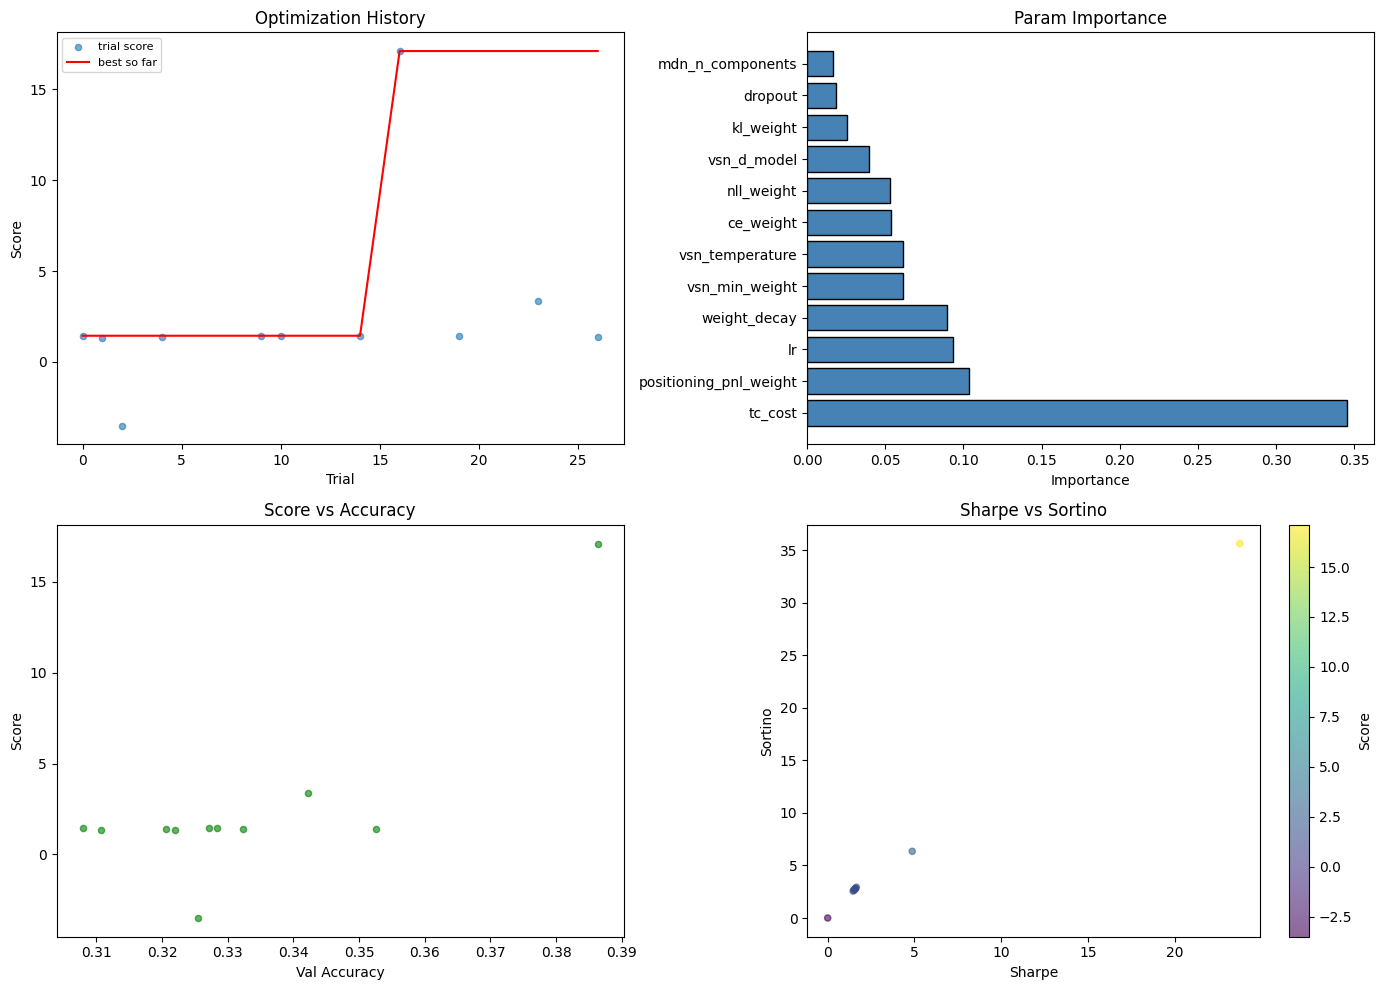

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
comp = trial_df[trial_df['status'] == 'COMPLETE'].copy()
best_so_far = comp['score'].expanding().max()
axes[0, 0].scatter(comp['trial'], comp['score'], s=20, alpha=0.6, label='trial score')
axes[0, 0].plot(comp['trial'].values, best_so_far.values, color='red', lw=1.5, label='best so far')
axes[0, 0].set_xlabel('Trial'); axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Optimization History'); axes[0, 0].legend(fontsize=8)

try:
    imp = optuna.importance.get_param_importances(study)
    names, vals = list(imp.keys())[:12], list(imp.values())[:12]
    axes[0, 1].barh(names, vals, color='steelblue', edgecolor='black')
    axes[0, 1].set_xlabel('Importance'); axes[0, 1].set_title('Param Importance')
except Exception:
    axes[0, 1].text(0.5, 0.5, 'Not enough data', ha='center', va='center',
                    transform=axes[0, 1].transAxes)

if 'accuracy' in comp.columns:
    axes[1, 0].scatter(comp['accuracy'], comp['score'], s=20, alpha=0.6, c='green')
    axes[1, 0].set_xlabel('Val Accuracy'); axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Score vs Accuracy')

if 'sharpe' in comp.columns:
    sc = axes[1, 1].scatter(comp['sharpe'], comp['sortino'], s=20, alpha=0.6,
                            c=comp['score'], cmap='viridis')
    axes[1, 1].set_xlabel('Sharpe'); axes[1, 1].set_ylabel('Sortino')
    axes[1, 1].set_title('Sharpe vs Sortino'); plt.colorbar(sc, ax=axes[1, 1], label='Score')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'optuna_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Train Final Model

In [20]:
bp = selected_trial.params

final_cfg = HybridConfig(
    n_features=n_features, seq_len=SEQ_LEN,
    f_ae=12, ae_window=ae_window_bars,
    d_latent=bp['d_latent'], d_ae_hidden=bp['d_ae_hidden'],
    kl_weight=bp['kl_weight'], recon_weight=bp['recon_weight'],
    tcn_channels=[bp['tcn_width']]*bp['tcn_depth'], tcn_kernel_size=3,
    stride=bp['stride'],
    mdn_hidden_dims=[bp['mdn_hidden'], bp['mdn_hidden']//2],
    mdn_n_components=bp['mdn_n_components'],
    head_hidden_dim=bp['head_hidden_dim'], dropout=bp['dropout'],
    nll_weight=bp['nll_weight'],
    n_classes=N_CLASSES, use_positioning_head=USE_POSITIONING,
    positioning_hidden_dim=bp['positioning_hidden_dim'],
    ce_weight=bp['ce_weight'], positioning_pnl_weight=bp['positioning_pnl_weight'],
    tc_cost=bp['tc_cost'],
    use_vsn=USE_VSN,
    vsn_d_model=bp.get('vsn_d_model', 32),
    vsn_temperature=bp.get('vsn_temperature', 1.5),
    vsn_entropy_weight=bp.get('vsn_entropy_weight', 0.1),
    vsn_min_weight=bp.get('vsn_min_weight', 0.05),
)

model = HybridMixtureNetwork(
    final_cfg, feature_group_sizes=FEATURE_GROUP_SIZES if USE_VSN else None,
).to(DEVICE)
loss_fn = HybridLoss(final_cfg)
optimizer = optim.AdamW(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2)

FINAL_BS = bp['batch_size']
train_loader = DataLoader(train_ds, batch_size=FINAL_BS, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=FINAL_BS, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=FINAL_BS, shuffle=False)

print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trial        : #{selected_trial.number} (rank {TRIAL_RANK + 1})')
print(f'Stride       : {bp["stride"]}')
print(f'VSN groups   : {list(FEATURE_GROUP_SIZES.keys()) if USE_VSN else "disabled"}')

Model params : 3,448,632
Trial        : #16 (rank 1)
Stride       : 2
VSN groups   : ['technical', 'storage', 'weather']


In [21]:
MAX_EPOCHS = 200
PATIENCE   = 20
LOG_EVERY  = 20

loss_keys = ['total_loss', 'return_loss', 'vol_loss', 'mdn_nll_loss',
             'ae_recon_loss', 'ae_kl_loss', 'vsn_entropy_loss']
if N_CLASSES > 0: loss_keys.extend(['ce_loss', 'class_accuracy'])
if USE_POSITIONING: loss_keys.extend(['positioning_loss', 'mean_position', 'mean_strategy_ret'])

history = {f'train_{k}': [] for k in loss_keys}
history.update({f'val_{k}': [] for k in loss_keys})
for k in ['val_sharpe','val_sortino','val_score','val_profit_factor',
          'val_win_rate','val_max_drawdown','val_direction_accuracy','val_return_corr']:
    history[k] = []
for gname in FEATURE_GROUP_SIZES:
    history[f'val_vsn_{gname}'] = []

best_val_loss, best_state, best_metrics, patience_cnt = float('inf'), None, {}, 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_train = {k: [] for k in loss_keys}
    for batch in train_loader:
        if len(batch) == 5:
            x_seq, ae_in, y_ret, y_std, y_cls = batch; y_cls = y_cls.to(DEVICE)
        else:
            x_seq, ae_in, y_ret, y_std = batch; y_cls = None
        x_seq, ae_in = x_seq.to(DEVICE), ae_in.to(DEVICE)
        y_ret, y_std = y_ret.to(DEVICE), y_std.to(DEVICE)
        optimizer.zero_grad()
        out = model(x_seq, ae_in)
        losses = loss_fn(out, y_ret, y_std, y_cls)
        losses['total_loss'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        for k in loss_keys:
            if k in losses:
                v = losses[k]
                epoch_train[k].append(v.item() if torch.is_tensor(v) else v)
    scheduler.step()

    model.eval()
    epoch_val = {k: [] for k in loss_keys}
    with torch.no_grad():
        for batch in val_loader:
            if len(batch) == 5:
                x_seq, ae_in, y_ret, y_std, y_cls = batch; y_cls = y_cls.to(DEVICE)
            else:
                x_seq, ae_in, y_ret, y_std = batch; y_cls = None
            x_seq, ae_in = x_seq.to(DEVICE), ae_in.to(DEVICE)
            y_ret, y_std = y_ret.to(DEVICE), y_std.to(DEVICE)
            out = model(x_seq, ae_in)
            losses = loss_fn(out, y_ret, y_std, y_cls)
            for k in loss_keys:
                if k in losses:
                    v = losses[k]
                    epoch_val[k].append(v.item() if torch.is_tensor(v) else v)

    for k in loss_keys:
        history[f'train_{k}'].append(np.mean(epoch_train[k]) if epoch_train[k] else 0)
        history[f'val_{k}'].append(np.mean(epoch_val[k]) if epoch_val[k] else 0)

    val_loss = history['val_total_loss'][-1]
    is_new_best = val_loss < best_val_loss
    if is_new_best:
        best_val_loss = val_loss; best_state = copy.deepcopy(model.state_dict()); patience_cnt = 0
    else:
        patience_cnt += 1

    should_log = (epoch % LOG_EVERY == 0) or (epoch == 1) or is_new_best
    if should_log:
        val_metrics = compute_val_metrics(model, val_loader, loss_fn, DEVICE)
        score = selection_score(val_metrics)
        if is_new_best: best_metrics = val_metrics.copy()
    else:
        val_metrics = {}
        score = history['val_score'][-1] if history['val_score'] else 0

    def _get(key, dk=None):
        if key in val_metrics: return val_metrics[key]
        h = history.get(dk or f'val_{key}', []); return h[-1] if h else 0

    history['val_sharpe'].append(_get('sharpe','val_sharpe'))
    history['val_sortino'].append(_get('sortino','val_sortino'))
    history['val_score'].append(score)
    history['val_profit_factor'].append(_get('profit_factor','val_profit_factor'))
    history['val_win_rate'].append(_get('win_rate','val_win_rate'))
    history['val_max_drawdown'].append(_get('max_drawdown','val_max_drawdown'))
    history['val_direction_accuracy'].append(_get('direction_accuracy','val_direction_accuracy'))
    history['val_return_corr'].append(_get('return_corr','val_return_corr'))
    for gn in FEATURE_GROUP_SIZES:
        history[f'val_vsn_{gn}'].append(_get(f'vsn_{gn}', f'val_vsn_{gn}'))

    if should_log:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'\n--- Epoch {epoch:3d}/{MAX_EPOCHS} {"[NEW BEST]" if is_new_best else ""} '
              f'(patience={patience_cnt}/{PATIENCE}, lr={lr_now:.2e}) ---')
        print(f'  Train: total={history["train_total_loss"][-1]:.5f}  '
              f'nll={history["train_mdn_nll_loss"][-1]:.5f}')
        print(f'  Val  : total={val_loss:.5f}  nll={history["val_mdn_nll_loss"][-1]:.5f}')
        print(_fmt_metrics(val_metrics, prefix='  '))
        print(f'  Score={score:.3f}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}'); break

print(f'\n{"="*70}')
print(f'Training complete  epochs={epoch}  best_val_loss={best_val_loss:.5f}')
print(_fmt_metrics(best_metrics, prefix='  '))
print(f'  Score={selection_score(best_metrics):.3f}')
print(f'{"="*70}')


--- Epoch   1/200 [NEW BEST] (patience=0/20, lr=1.75e-04) ---
  Train: total=5386919.36330  nll=0.22925
  Val  : total=2.45127  nll=-0.24775
  Losses   : val_loss=2.44686, return_loss=0.00032, vol_loss=0.44124, mdn_nll_loss=-0.24766, ce_loss=1.35953, positioning_loss=0.04136
  Class    : acc=0.308, c0=0.000(3506), c1=0.000(2041), c2=0.000(1909), c3=1.000(3317)
  Position : sharpe=-1.477, sortino=-1.743, pf=0.96, win=51.5%, maxDD=-0.0887
  Returns  : mae=0.01928, corr=0.032, dir_acc=0.520
  VSN      : entropy_loss=0.000, technical=0.279, storage=0.354, weather=0.367
  Score=-0.755

--- Epoch   2/200 [NEW BEST] (patience=0/20, lr=1.74e-04) ---
  Train: total=16.42659  nll=-0.31439
  Val  : total=1.66566  nll=-1.01089
  Losses   : val_loss=1.66446, return_loss=0.00033, vol_loss=0.10604, mdn_nll_loss=-1.01094, ce_loss=1.36532, positioning_loss=0.04157
  Class    : acc=0.328, c0=0.845(3506), c1=0.000(2041), c2=0.000(1909), c3=0.172(3317)
  Position : sharpe=-1.628, sortino=-1.914, pf=0.96,

In [22]:
if best_state:
    model.load_state_dict(best_state)
    print('Loaded best model state')

Loaded best model state


## 12. Training Diagnostics

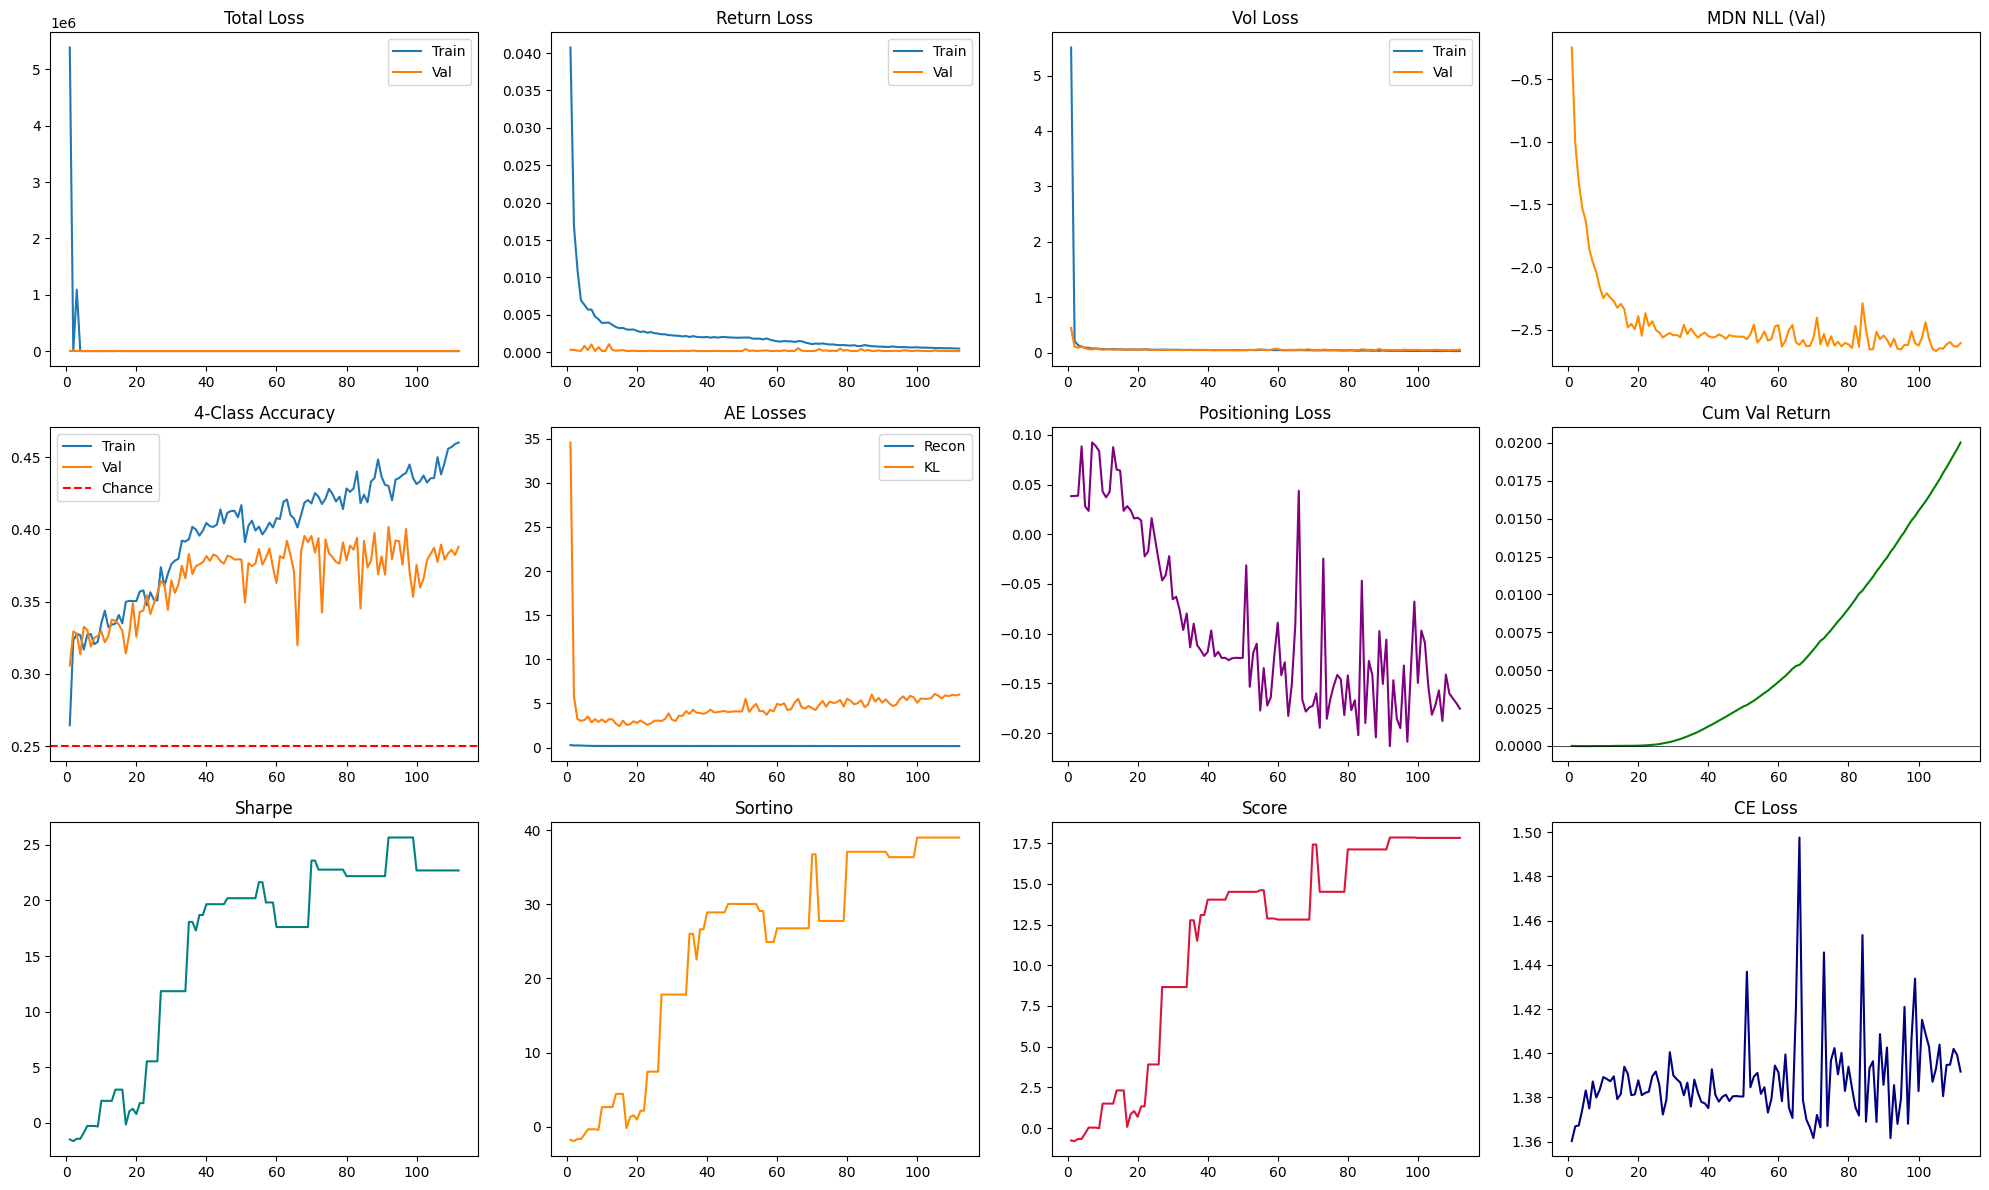

In [23]:
ep = range(1, len(history['train_total_loss']) + 1)
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

axes[0,0].plot(ep, history['train_total_loss'], label='Train')
axes[0,0].plot(ep, history['val_total_loss'], label='Val')
axes[0,0].set_title('Total Loss'); axes[0,0].legend()

axes[0,1].plot(ep, history['train_return_loss'], label='Train')
axes[0,1].plot(ep, history['val_return_loss'], label='Val')
axes[0,1].set_title('Return Loss'); axes[0,1].legend()

axes[0,2].plot(ep, history['train_vol_loss'], label='Train')
axes[0,2].plot(ep, history['val_vol_loss'], label='Val')
axes[0,2].set_title('Vol Loss'); axes[0,2].legend()

axes[0,3].plot(ep, history['val_mdn_nll_loss'], color='darkorange')
axes[0,3].set_title('MDN NLL (Val)')

if 'val_class_accuracy' in history and history['val_class_accuracy']:
    axes[1,0].plot(ep, history['train_class_accuracy'], label='Train')
    axes[1,0].plot(ep, history['val_class_accuracy'], label='Val')
    axes[1,0].axhline(1/N_CLASSES, color='red', ls='--', label='Chance')
    axes[1,0].set_title(f'{N_CLASSES}-Class Accuracy'); axes[1,0].legend()
else:
    axes[1,0].axis('off')

axes[1,1].plot(ep, history['val_ae_recon_loss'], label='Recon')
axes[1,1].plot(ep, history['val_ae_kl_loss'], label='KL')
axes[1,1].set_title('AE Losses'); axes[1,1].legend()

if 'val_positioning_loss' in history:
    axes[1,2].plot(ep, history['val_positioning_loss'], color='purple')
    axes[1,2].set_title('Positioning Loss')
else: axes[1,2].axis('off')

if 'val_mean_strategy_ret' in history:
    axes[1,3].plot(ep, np.cumsum(history['val_mean_strategy_ret']), color='green')
    axes[1,3].axhline(0, color='black', lw=0.5); axes[1,3].set_title('Cum Val Return')
else: axes[1,3].axis('off')

axes[2,0].plot(ep, history['val_sharpe'], color='teal'); axes[2,0].set_title('Sharpe')
axes[2,1].plot(ep, history['val_sortino'], color='darkorange'); axes[2,1].set_title('Sortino')
axes[2,2].plot(ep, history['val_score'], color='crimson'); axes[2,2].set_title('Score')
axes[2,3].plot(ep, history.get('val_ce_loss', []), color='navy'); axes[2,3].set_title('CE Loss')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. VSN Group Weights

Group                Avg      Std
technical         0.3274   0.0054
storage           0.3301   0.0098
weather           0.3425   0.0064


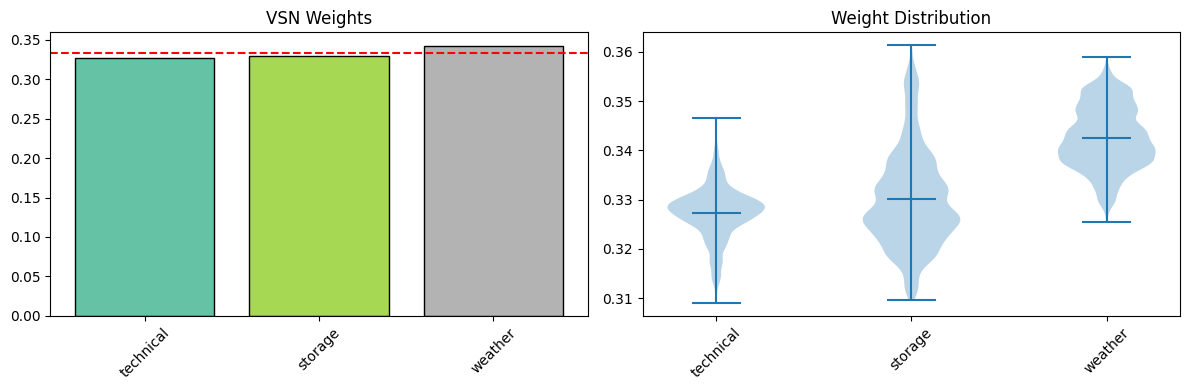

In [24]:
if USE_VSN and model.vsn is not None:
    model.eval()
    all_vsn = []
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch[0].to(DEVICE), batch[1].to(DEVICE))
            if 'vsn_weights' in out:
                all_vsn.append(out['vsn_weights'].cpu().numpy())
    if all_vsn:
        vsn_w = np.concatenate(all_vsn)
        gnames = list(FEATURE_GROUP_SIZES.keys())
        avg = vsn_w.mean(axis=0)
        print(f'{"Group":<15} {"Avg":>8} {"Std":>8}')
        for i, n in enumerate(gnames):
            print(f'{n:<15} {avg[i]:>8.4f} {vsn_w[:,i].std():>8.4f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(gnames, avg, color=plt.cm.Set2(np.linspace(0,1,len(gnames))), edgecolor='black')
        axes[0].axhline(1/len(gnames), color='red', ls='--'); axes[0].set_title('VSN Weights')
        axes[0].tick_params(axis='x', rotation=45)
        axes[1].violinplot([vsn_w[:,i] for i in range(len(gnames))],
                           positions=range(len(gnames)), showmeans=True)
        axes[1].set_xticks(range(len(gnames))); axes[1].set_xticklabels(gnames, rotation=45)
        axes[1].set_title('Weight Distribution')
        plt.tight_layout(); plt.savefig(SAVE_DIR / 'vsn_weights.png', dpi=150); plt.show()
else:
    print('VSN disabled')

## 14. Backtest

In [25]:
def evaluate_split(ds, loader, name):
    model.eval()
    preds_ret, actuals_ret, positions, pred_classes, actual_classes = [], [], [], [], []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 5:
                x_seq, ae_in, y_ret, y_std, y_cls = batch
            else:
                x_seq, ae_in, y_ret, y_std = batch; y_cls = None
            out = model(x_seq.to(DEVICE), ae_in.to(DEVICE))
            preds_ret.append(out['pred_return'].cpu().numpy())
            actuals_ret.append(y_ret.numpy())
            if 'class_logits' in out:
                pred_classes.append(out['class_logits'].argmax(dim=-1).cpu().numpy())
            if y_cls is not None: actual_classes.append(y_cls.numpy())
            if 'position' in out: positions.append(out['position'].cpu().numpy())

    pr, ar = np.concatenate(preds_ret), np.concatenate(actuals_ret)
    dates = [ds.get_date(i) for i in range(len(ds))]
    dm = np.abs(ar) > 1e-6
    print(f'\n=== {name} ({len(ds)} samples) ===')
    print(f'  MAE={np.abs(pr-ar).mean():.5f}  Corr={np.corrcoef(pr,ar)[0,1]:.4f}  '
          f'Dir={( np.sign(pr[dm])==np.sign(ar[dm]) ).mean():.3f}')

    if pred_classes and actual_classes:
        pc, ac = np.concatenate(pred_classes), np.concatenate(actual_classes)
        print(f'  Class acc: {(pc==ac).mean():.3f}')

    if positions:
        pos = np.concatenate(positions)
        sr = pos * ar; cum = np.cumsum(sr)
        ann = np.sqrt(252 * bars_per_day)
        sharpe = sr.mean()/sr.std()*ann if sr.std()>0 else 0
        dd = sr[sr<0]; sortino = sr.mean()/dd.std()*ann if len(dd)>1 and dd.std()>0 else 0
        mdd = (cum - np.maximum.accumulate(cum)).min()
        print(f'  Sharpe={sharpe:.3f}  Sortino={sortino:.3f}  MaxDD={mdd:.4f}  TotalRet={cum[-1]:.4f}')
        return {'dates': dates, 'positions': pos, 'strategy_ret': sr, 'cum_ret': cum}
    return {'dates': dates}

val_results = evaluate_split(val_ds, val_loader, 'Validation')
test_results = evaluate_split(test_ds, test_loader, 'Test')


=== Validation (10773 samples) ===
  MAE=0.01241  Corr=0.2033  Dir=0.581
  Class acc: 0.401
  Sharpe=25.649  Sortino=36.347  MaxDD=-0.1618  TotalRet=3.9856

=== Test (10775 samples) ===
  MAE=0.01223  Corr=0.1675  Dir=0.564
  Class acc: 0.373
  Sharpe=19.923  Sortino=26.993  MaxDD=-0.1784  TotalRet=3.1963


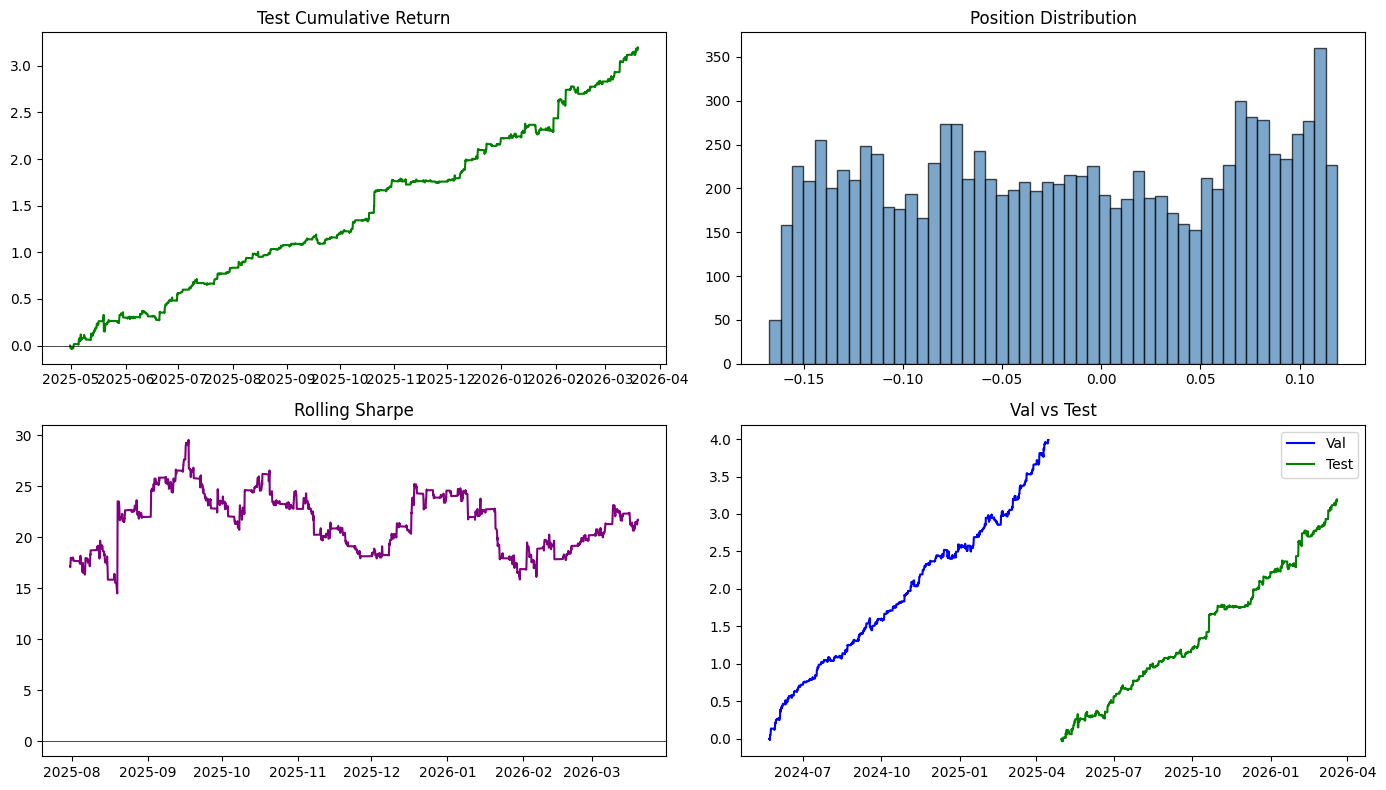

In [26]:
if 'cum_ret' in test_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes[0,0].plot(test_results['dates'], test_results['cum_ret'], color='green')
    axes[0,0].axhline(0, color='black', lw=0.5); axes[0,0].set_title('Test Cumulative Return')
    axes[0,1].hist(test_results['positions'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0,1].set_title('Position Distribution')
    sr = pd.Series(test_results['strategy_ret'])
    rs = sr.rolling(60*bars_per_day).mean()/sr.rolling(60*bars_per_day).std()*np.sqrt(252*bars_per_day)
    axes[1,0].plot(test_results['dates'], rs.values, color='purple')
    axes[1,0].axhline(0, color='black', lw=0.5); axes[1,0].set_title('Rolling Sharpe')
    if 'cum_ret' in val_results:
        axes[1,1].plot(val_results['dates'], val_results['cum_ret'], color='blue', label='Val')
        axes[1,1].plot(test_results['dates'], test_results['cum_ret'], color='green', label='Test')
        axes[1,1].legend(); axes[1,1].set_title('Val vs Test')
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'backtest.png', dpi=150, bbox_inches='tight'); plt.show()

## 14a. Detailed Backtest Analysis

Rolling feature group weights, calendar PnL patterns (day-of-week, EIA release days), drawdown analysis, and regime decomposition.

In [ ]:
# === Collect per-bar backtest DataFrame with model outputs ===
# Run inference on test set, capturing predictions, positions, VSN weights, and timestamps.

model.eval()
bt_records = []
vsn_active = USE_VSN and model.vsn is not None

with torch.no_grad():
    for sample_idx in range(len(test_ds)):
        sample = test_ds[sample_idx]
        ts = test_ds.get_date(sample_idx)

        if len(sample) == 5:
            x_seq, ae_in, y_ret, y_std, y_cls = sample
        else:
            x_seq, ae_in, y_ret, y_std = sample
            y_cls = None

        x_seq_b = x_seq.unsqueeze(0).to(DEVICE)
        ae_in_b = ae_in.unsqueeze(0).to(DEVICE)
        out = model(x_seq_b, ae_in_b)

        rec = {
            'timestamp': ts,
            'pred_return': out['pred_return'].item(),
            'actual_return': y_ret.item(),
            'pred_std': out['pred_std'].item(),
            'actual_std': y_std.item(),
        }
        if 'position' in out:
            rec['position'] = out['position'].item()
            rec['strategy_ret'] = rec['position'] * rec['actual_return']
        if 'class_logits' in out:
            rec['pred_class'] = out['class_logits'].argmax(dim=-1).item()
        if y_cls is not None:
            rec['actual_class'] = y_cls.item()
        if vsn_active and 'vsn_weights' in out:
            w = out['vsn_weights'].cpu().numpy().squeeze()
            for gi, gname in enumerate(FEATURE_GROUP_SIZES.keys()):
                rec[f'vsn_{gname}'] = w[gi]

        bt_records.append(rec)

bt = pd.DataFrame(bt_records)
bt['timestamp'] = pd.to_datetime(bt['timestamp'])
bt = bt.set_index('timestamp').sort_index()
bt['cum_ret'] = bt['strategy_ret'].cumsum()
bt['date'] = bt.index.date
bt['dow'] = bt.index.dayofweek          # 0=Mon ... 4=Fri
bt['dow_name'] = bt.index.day_name()
bt['hour'] = bt.index.hour
bt['month'] = bt.index.month
bt['week'] = bt.index.isocalendar().week.astype(int).values

# Mark EIA release days (Thursdays 10:30 ET, or Wednesdays if holiday)
eia_dates = set(storage_wkly.index.normalize())
bt['is_eia_day'] = bt['date'].apply(lambda d: pd.Timestamp(d) in eia_dates)

print(f'Backtest DataFrame: {bt.shape}')
print(f'Date range: {bt.index[0]} to {bt.index[-1]}')
print(f'EIA release days in test: {bt["is_eia_day"].sum()} bars on {bt.groupby("date")["is_eia_day"].first().sum()} days')
print(f'Total strategy return: {bt["cum_ret"].iloc[-1]:.4f}')
bt.head()

In [ ]:
# === Rolling VSN feature group weights over time ===

vsn_cols = [c for c in bt.columns if c.startswith('vsn_')]
if vsn_cols:
    ROLL_W = 5 * bars_per_day   # 5-day rolling window

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # 1. Stacked area: rolling mean group weights
    roll_vsn = bt[vsn_cols].rolling(ROLL_W, min_periods=ROLL_W // 2).mean()
    gnames = [c.replace('vsn_', '') for c in vsn_cols]
    colors = plt.cm.Set2(np.linspace(0, 1, len(vsn_cols)))

    axes[0].stackplot(roll_vsn.index, *[roll_vsn[c].values for c in vsn_cols],
                      labels=gnames, colors=colors, alpha=0.85)
    axes[0].set_ylabel('Group Weight Share')
    axes[0].set_title(f'Rolling {ROLL_W // bars_per_day}-Day VSN Group Weights (Stacked)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_ylim(0, 1)

    # 2. Individual lines: rolling mean per group
    for ci, col in enumerate(vsn_cols):
        axes[1].plot(roll_vsn.index, roll_vsn[col], label=gnames[ci],
                     color=colors[ci], lw=1.5)
    axes[1].axhline(1 / len(vsn_cols), color='red', ls='--', lw=0.8, label='uniform')
    axes[1].set_ylabel('Weight')
    axes[1].set_title('Individual Group Weight Trajectories')
    axes[1].legend(loc='upper right', fontsize=8)

    # 3. Overlay cum return for context
    ax_ret = axes[2]
    ax_ret.plot(bt.index, bt['cum_ret'], color='black', lw=1.2, label='Cum Return')
    ax_ret.fill_between(bt.index, bt['cum_ret'], 0,
                        where=bt['cum_ret'] >= 0, color='green', alpha=0.15)
    ax_ret.fill_between(bt.index, bt['cum_ret'], 0,
                        where=bt['cum_ret'] < 0, color='red', alpha=0.15)
    ax_ret.set_ylabel('Cumulative Return')
    ax_ret.set_title('Cumulative Strategy Return')
    ax_ret.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'rolling_vsn_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Print dominant group per rolling window ---
    dominant = roll_vsn.dropna().idxmax(axis=1).value_counts()
    print('\nDominant group frequency (per bar):')
    for g, cnt in dominant.items():
        print(f'  {g.replace("vsn_",""):15s}: {cnt:5d} bars ({cnt/len(roll_vsn.dropna())*100:.1f}%)')
else:
    print('VSN disabled — no per-group weight data available')

In [ ]:
# === Calendar PnL patterns: Day-of-week, EIA release, hour-of-day ===

daily_pnl = bt.groupby('date').agg(
    strategy_ret=('strategy_ret', 'sum'),
    n_bars=('strategy_ret', 'count'),
    mean_pos=('position', 'mean'),
    is_eia_day=('is_eia_day', 'first'),
    dow=('dow', 'first'),
    dow_name=('dow_name', 'first'),
    month=('month', 'first'),
)
daily_pnl.index = pd.DatetimeIndex(daily_pnl.index)
ann = np.sqrt(252)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- 1. Day-of-week bar chart ---
dow_stats = daily_pnl.groupby('dow_name')['strategy_ret'].agg(['mean', 'std', 'count'])
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow_stats = dow_stats.reindex(dow_order)
dow_sharpe = (dow_stats['mean'] / dow_stats['std'] * ann).fillna(0)
colors_dow = ['green' if m > 0 else 'red' for m in dow_stats['mean']]
axes[0, 0].bar(dow_order, dow_stats['mean'] * 1e4, color=colors_dow, edgecolor='black', alpha=0.8)
for i, (d, s) in enumerate(zip(dow_order, dow_sharpe)):
    axes[0, 0].text(i, dow_stats['mean'].iloc[i] * 1e4 + 0.1, f'SR={s:.2f}',
                    ha='center', fontsize=8)
axes[0, 0].set_ylabel('Mean Daily Return (bps)')
axes[0, 0].set_title('PnL by Day of Week')
axes[0, 0].tick_params(axis='x', rotation=30)

# --- 2. EIA release day vs non-release ---
eia_pnl = daily_pnl.groupby('is_eia_day')['strategy_ret'].agg(['mean', 'std', 'count'])
eia_sharpe = (eia_pnl['mean'] / eia_pnl['std'] * ann).fillna(0)
labels = ['Non-EIA Days', 'EIA Release Days']
colors_eia = ['steelblue', 'darkorange']
axes[0, 1].bar(labels, eia_pnl['mean'] * 1e4, color=colors_eia, edgecolor='black', alpha=0.8)
for i, (sr, cnt) in enumerate(zip(eia_sharpe, eia_pnl['count'])):
    axes[0, 1].text(i, eia_pnl['mean'].iloc[i] * 1e4 + 0.1,
                    f'SR={sr:.2f}\nn={cnt}', ha='center', fontsize=8)
axes[0, 1].set_ylabel('Mean Daily Return (bps)')
axes[0, 1].set_title('EIA Release Day Effect')

# --- 3. Hour-of-day heatmap ---
hourly = bt.groupby('hour')['strategy_ret'].agg(['mean', 'std', 'count'])
hourly_sharpe = (hourly['mean'] / hourly['std'] * np.sqrt(252 * bars_per_day)).fillna(0)
colors_hr = ['green' if m > 0 else 'red' for m in hourly['mean']]
axes[0, 2].bar(hourly.index, hourly['mean'] * 1e4, color=colors_hr, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Hour')
axes[0, 2].set_ylabel('Mean Return (bps)')
axes[0, 2].set_title('PnL by Hour of Day')

# --- 4. Monthly cumulative return heatmap ---
monthly = daily_pnl.groupby('month')['strategy_ret'].agg(['sum', 'mean', 'std', 'count'])
monthly_sharpe = (monthly['mean'] / monthly['std'] * ann).fillna(0)
colors_mo = ['green' if s > 0 else 'red' for s in monthly['sum']]
axes[1, 0].bar(monthly.index, monthly['sum'] * 1e4, color=colors_mo, edgecolor='black', alpha=0.8)
for i, (mo, sr) in enumerate(zip(monthly.index, monthly_sharpe)):
    axes[1, 0].text(mo, monthly['sum'].iloc[i] * 1e4 + 0.1, f'SR={sr:.2f}',
                    ha='center', fontsize=7)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Return (bps)')
axes[1, 0].set_title('PnL by Calendar Month')

# --- 5. Drawdown chart ---
cum = bt['cum_ret'].values
running_max = np.maximum.accumulate(cum)
drawdown = cum - running_max
axes[1, 1].fill_between(bt.index, drawdown, 0, color='red', alpha=0.4)
axes[1, 1].set_ylabel('Drawdown')
axes[1, 1].set_title(f'Drawdown (Max: {drawdown.min():.4f})')

# Find top-5 drawdown troughs
dd_series = pd.Series(drawdown, index=bt.index)
trough_idx = dd_series.nsmallest(5).index
for ti in trough_idx:
    axes[1, 1].axvline(ti, color='black', ls='--', lw=0.5, alpha=0.5)

# --- 6. Rolling daily Sharpe (20-day) ---
daily_sr = daily_pnl['strategy_ret']
roll_sharpe = daily_sr.rolling(20, min_periods=10).mean() / daily_sr.rolling(20, min_periods=10).std() * ann
axes[1, 2].plot(daily_pnl.index, roll_sharpe.values, color='purple', lw=1)
axes[1, 2].axhline(0, color='black', lw=0.5)
axes[1, 2].axhline(1, color='green', ls='--', lw=0.5, alpha=0.5)
axes[1, 2].axhline(-1, color='red', ls='--', lw=0.5, alpha=0.5)
axes[1, 2].set_ylabel('Sharpe Ratio')
axes[1, 2].set_title('Rolling 20-Day Sharpe')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'calendar_pnl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary table ---
print(f'\n{"="*70}')
print('Calendar PnL Summary')
print(f'{"="*70}')
print(f'\n{"Day":<12} {"MeanRet(bps)":>12} {"Sharpe":>8} {"Count":>6}')
print('-' * 42)
for d in dow_order:
    r = dow_stats.loc[d]
    s = dow_sharpe.loc[d]
    print(f'{d:<12} {r["mean"]*1e4:>12.2f} {s:>8.2f} {int(r["count"]):>6}')

print(f'\n{"Category":<20} {"MeanRet(bps)":>12} {"Sharpe":>8} {"Days":>6}')
print('-' * 50)
for label, is_eia in [('Non-EIA Days', False), ('EIA Release Days', True)]:
    r = eia_pnl.loc[is_eia]
    s = eia_sharpe.loc[is_eia]
    print(f'{label:<20} {r["mean"]*1e4:>12.2f} {s:>8.2f} {int(r["count"]):>6}')

In [ ]:
# === VSN weights conditioned on calendar: do groups shift on EIA days? ===

vsn_cols = [c for c in bt.columns if c.startswith('vsn_')]
if vsn_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    gnames = [c.replace('vsn_', '') for c in vsn_cols]
    x_pos = np.arange(len(gnames))
    bar_w = 0.35

    # 1. EIA vs non-EIA group weights
    eia_w = bt[bt['is_eia_day']][vsn_cols].mean()
    non_eia_w = bt[~bt['is_eia_day']][vsn_cols].mean()
    axes[0].bar(x_pos - bar_w/2, non_eia_w.values, bar_w, label='Non-EIA', color='steelblue')
    axes[0].bar(x_pos + bar_w/2, eia_w.values, bar_w, label='EIA Day', color='darkorange')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(gnames, rotation=30)
    axes[0].set_ylabel('Mean Weight')
    axes[0].set_title('VSN Weights: EIA vs Non-EIA')
    axes[0].legend()

    # 2. Day-of-week heatmap
    dow_vsn = bt.groupby('dow_name')[vsn_cols].mean().reindex(
        ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
    dow_vsn.columns = gnames
    im = axes[1].imshow(dow_vsn.values, aspect='auto', cmap='YlOrRd')
    axes[1].set_xticks(range(len(gnames)))
    axes[1].set_xticklabels(gnames, rotation=30, fontsize=8)
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels(dow_vsn.index, fontsize=9)
    for r in range(dow_vsn.shape[0]):
        for c in range(dow_vsn.shape[1]):
            axes[1].text(c, r, f'{dow_vsn.iloc[r, c]:.3f}', ha='center', va='center', fontsize=7)
    axes[1].set_title('VSN Weights by Day-of-Week')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # 3. Correlation: VSN weight change vs strategy return
    # Per-day: which group weight shift correlates with PnL?
    daily_vsn = bt.groupby('date')[vsn_cols + ['strategy_ret']].mean()
    corrs = daily_vsn[vsn_cols].corrwith(daily_vsn['strategy_ret'])
    colors_corr = ['green' if c > 0 else 'red' for c in corrs]
    axes[2].barh(gnames, corrs.values, color=colors_corr, edgecolor='black', alpha=0.8)
    axes[2].axvline(0, color='black', lw=0.5)
    axes[2].set_xlabel('Correlation with Daily PnL')
    axes[2].set_title('VSN Group Weight vs Strategy Return')

    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'vsn_calendar_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Statistical test: are EIA-day weights significantly different? ---
    from scipy import stats
    print(f'\nEIA vs Non-EIA weight shift (t-test):')
    print(f'{"Group":<15} {"Non-EIA":>8} {"EIA":>8} {"Diff":>8} {"t-stat":>8} {"p-val":>8}')
    print('-' * 60)
    for col, gn in zip(vsn_cols, gnames):
        a = bt[~bt['is_eia_day']][col]
        b = bt[bt['is_eia_day']][col]
        t, p = stats.ttest_ind(a, b, equal_var=False)
        print(f'{gn:<15} {a.mean():>8.4f} {b.mean():>8.4f} {b.mean()-a.mean():>+8.4f} {t:>8.2f} {p:>8.4f}')
else:
    print('VSN disabled')

In [ ]:
# === Comprehensive backtest statistics ===

sr = bt['strategy_ret']
pos = bt['position']
cum = bt['cum_ret']
n_days = len(daily_pnl)
ann_factor = np.sqrt(252)

# Overall stats
total_ret = cum.iloc[-1]
sharpe = sr.mean() / sr.std() * np.sqrt(252 * bars_per_day) if sr.std() > 0 else 0
ds = sr[sr < 0]
sortino = sr.mean() / ds.std() * np.sqrt(252 * bars_per_day) if len(ds) > 1 and ds.std() > 0 else 0
max_dd = (cum - np.maximum.accumulate(cum.values)).min()
g, l = sr[sr > 0].sum(), abs(sr[sr < 0].sum())
pf = g / max(l, 1e-8)
win_rate = (sr > 0).mean()
daily_sharpe = daily_pnl['strategy_ret'].mean() / daily_pnl['strategy_ret'].std() * ann_factor if daily_pnl['strategy_ret'].std() > 0 else 0

# Calmar ratio
ann_ret = daily_pnl['strategy_ret'].mean() * 252
calmar = ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0

# Win/loss streaks
daily_wins = (daily_pnl['strategy_ret'] > 0).astype(int)
streaks = daily_wins.diff().ne(0).cumsum()
win_streaks = daily_wins.groupby(streaks).sum()
loss_streaks = (1 - daily_wins).groupby(streaks).sum()
max_win_streak = win_streaks.max()
max_loss_streak = loss_streaks.max()

# Drawdown duration
dd_arr = (cum - np.maximum.accumulate(cum.values)).values
in_dd = dd_arr < -1e-8
dd_durations = []
curr = 0
for v in in_dd:
    if v:
        curr += 1
    else:
        if curr > 0:
            dd_durations.append(curr)
        curr = 0
if curr > 0:
    dd_durations.append(curr)
max_dd_bars = max(dd_durations) if dd_durations else 0
max_dd_days = max_dd_bars / bars_per_day if bars_per_day > 0 else 0

# Position analysis
mean_abs_pos = pos.abs().mean()
pos_pct_long = (pos > 0.01).mean()
pos_pct_short = (pos < -0.01).mean()
pos_pct_flat = 1 - pos_pct_long - pos_pct_short

# Prediction quality
dir_mask = bt['actual_return'].abs() > 1e-6
dir_acc = (np.sign(bt['pred_return']) == np.sign(bt['actual_return']))[dir_mask].mean()
ret_corr = np.corrcoef(bt['pred_return'], bt['actual_return'])[0, 1]

if 'pred_class' in bt.columns and 'actual_class' in bt.columns:
    cls_acc = (bt['pred_class'] == bt['actual_class']).mean()
else:
    cls_acc = None

print(f'{"="*60}')
print(f'  BACKTEST SUMMARY — Test Set')
print(f'{"="*60}')
print(f'  Period          : {bt.index[0].date()} to {bt.index[-1].date()} ({n_days} trading days)')
print(f'  Bars            : {len(bt):,} ({BAR_MINUTES}min)')
print(f'{"─"*60}')
print(f'  Total Return    : {total_ret:+.4f}')
print(f'  Ann. Return     : {ann_ret:+.4f}')
print(f'  Sharpe (bar)    : {sharpe:.3f}')
print(f'  Sharpe (daily)  : {daily_sharpe:.3f}')
print(f'  Sortino         : {sortino:.3f}')
print(f'  Calmar          : {calmar:.3f}')
print(f'  Profit Factor   : {pf:.2f}')
print(f'  Win Rate (bar)  : {win_rate:.1%}')
print(f'  Win Rate (daily): {(daily_pnl["strategy_ret"] > 0).mean():.1%}')
print(f'{"─"*60}')
print(f'  Max Drawdown    : {max_dd:.4f}')
print(f'  Max DD Duration : {max_dd_days:.1f} days ({max_dd_bars} bars)')
print(f'  Max Win Streak  : {max_win_streak} days')
print(f'  Max Loss Streak : {max_loss_streak} days')
print(f'{"─"*60}')
print(f'  Direction Acc   : {dir_acc:.3f}')
print(f'  Return Corr     : {ret_corr:.3f}')
if cls_acc is not None:
    print(f'  Class Accuracy  : {cls_acc:.3f}')
print(f'{"─"*60}')
print(f'  Mean |Position| : {mean_abs_pos:.3f}')
print(f'  % Long          : {pos_pct_long:.1%}')
print(f'  % Short         : {pos_pct_short:.1%}')
print(f'  % Flat (<0.01)  : {pos_pct_flat:.1%}')
print(f'{"="*60}')

# Save backtest DataFrame for further analysis
bt.to_csv(SAVE_DIR / 'backtest_detail.csv')
print(f'\nBacktest detail saved to {SAVE_DIR / "backtest_detail.csv"}')

## 14b. TCN Per-Feature Weight Importance

VSN active — computing per-group GRN-based feature importance
Rank  Feature                                     Weight     Cumul
------------------------------------------------------------------
   1  storage_change                              0.0384    0.0384
   2  sl_4wk_mean                                 0.0350    0.0734
   3  surprise                                    0.0330    0.1065
   4  sl_4wk_max                                  0.0295    0.1360
   5  sl_4wk_min                                  0.0280    0.1640
   6  dd_hdd_sp1                                  0.0279    0.1919
   7  consensus_est                               0.0274    0.2192
   8  dd_wtd_tavg_7d                              0.0270    0.2462
   9  dd_hdd_sp0                                  0.0266    0.2728
  10  storage_level                               0.0266    0.2994
  11  dd_hdd_7d_chg                               0.0264    0.3257
  12  sl_change_4wk_mean                          0.0254    0.3512


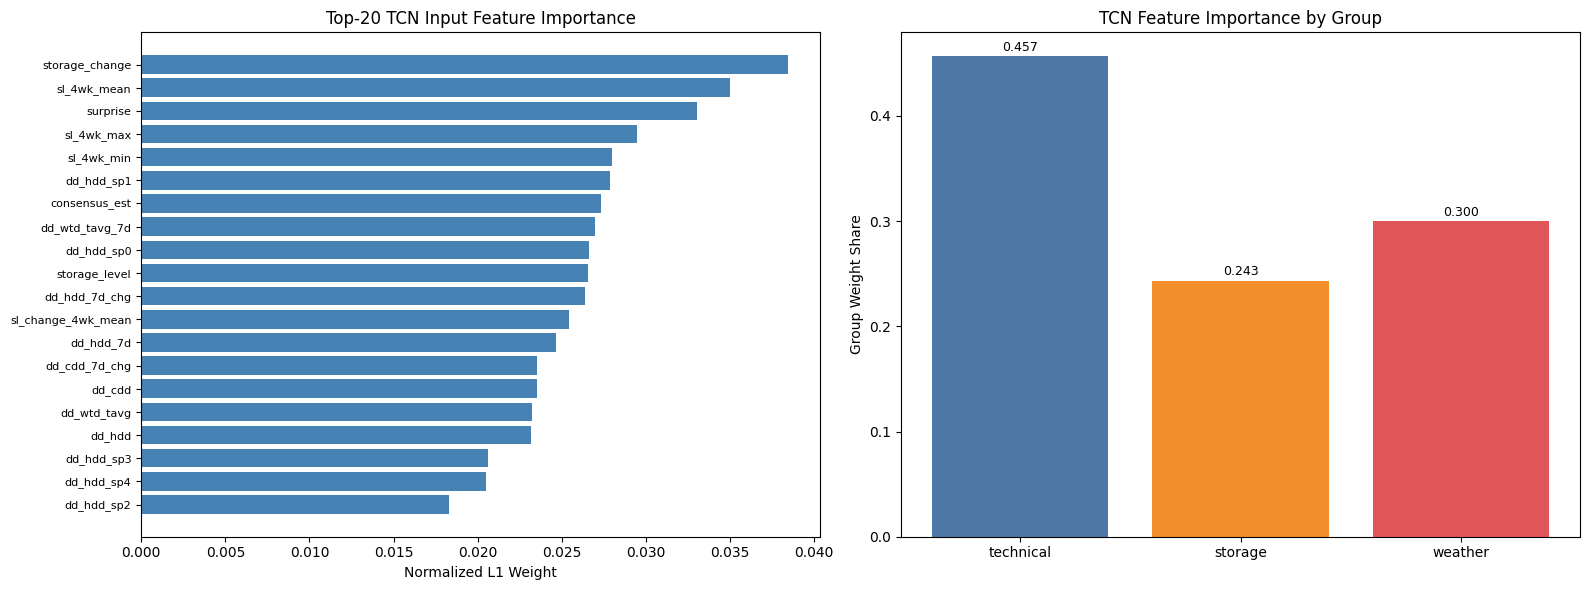


--- Gradient-based importance (top-15) ---
Rank  Feature                                    GradImp  WeightImp
------------------------------------------------------------------
   1  dd_hdd_7d_chg                               0.1691    0.0264
   2  dd_hdd_sp2                                  0.0951    0.0183
   3  dd_wtd_tavg_7d                              0.0857    0.0270
   4  dd_hdd                                      0.0822    0.0232
   5  dd_cdd_7d_chg                               0.0775    0.0235
   6  dd_hdd_sp4                                  0.0739    0.0205
   7  dd_cdd_7d                                   0.0682    0.0147
   8  dd_hdd_sp0                                  0.0637    0.0266
   9  dd_hdd_sp3                                  0.0624    0.0206
  10  dd_hdd_sp1                                  0.0622    0.0279
  11  dd_cdd                                      0.0540    0.0235
  12  dd_wtd_tavg                                 0.0521    0.0232
  13  dd_hdd_7d  

In [27]:
# --- TCN input_proj weight importance per feature ---
# When VSN is active, input_proj operates on d_model (VSN output), not raw features.
# In that case, use the VSN group weights + per-group GRN norms for feature importance.

W = model.input_proj.weight.detach().cpu()  # (tcn_ch0, feat_dim)
feat_names = all_feature_cols

if model.vsn is not None:
    # VSN active: input_proj sees d_model, not raw features.
    # Per-group importance = VSN selection weights (from last forward pass aren't stored,
    # so approximate via GRN L1 norms within each group + input_proj norm on d_model).
    print("VSN active — computing per-group GRN-based feature importance")

    # input_proj contribution per d_model dimension
    proj_importance = W.abs().sum(dim=0)  # (d_model,)

    feat_importance = np.zeros(len(feat_names))
    offset = 0
    for gi, (gname, gsize) in enumerate(FEATURE_GROUP_SIZES.items()):
        # First linear in the GRN: (d_model, n_feat_in_group)
        grn_w = model.vsn.group_grns[gi][0].weight.detach().cpu()  # (d_model, gsize)
        # Per raw feature: sum |grn_w| weighted by proj_importance
        raw_imp = (grn_w.abs() * proj_importance.unsqueeze(1)).sum(dim=0).numpy()  # (gsize,)
        feat_importance[offset:offset + gsize] = raw_imp
        offset += gsize

    feat_importance /= feat_importance.sum()
else:
    # No VSN: input_proj directly maps raw features
    assert len(feat_names) == W.shape[1], \
        f"Mismatch: {len(feat_names)} names vs {W.shape[1]} weights"
    feat_importance = W.abs().sum(dim=0).numpy()  # (n_features,)
    feat_importance /= feat_importance.sum()

# Sort descending
order = np.argsort(feat_importance)[::-1]
sorted_names = [feat_names[i] for i in order]
sorted_imp = feat_importance[order]

# Print table
print(f'{"Rank":>4}  {"Feature":<40}  {"Weight":>8}  {"Cumul":>8}')
print('-' * 66)
cumul = 0.0
for rank, (name, imp) in enumerate(zip(sorted_names, sorted_imp), 1):
    cumul += imp
    print(f'{rank:4d}  {name:<40}  {imp:8.4f}  {cumul:8.4f}')

# Plot top-20
top_n = min(20, len(sorted_names))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: top features
axes[0].barh(range(top_n), sorted_imp[:top_n][::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(sorted_names[:top_n][::-1], fontsize=8)
axes[0].set_xlabel('Normalized L1 Weight')
axes[0].set_title(f'Top-{top_n} TCN Input Feature Importance')

# Group-level aggregation
group_imp = {}
offset = 0
for gname, gsize in FEATURE_GROUP_SIZES.items():
    group_imp[gname] = feat_importance[offset:offset+gsize].sum()
    offset += gsize
gnames = list(group_imp.keys())
gvals = [group_imp[g] for g in gnames]
axes[1].bar(gnames, gvals, color=['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
                                    '#edc948','#b07aa1'][:len(gnames)])
axes[1].set_ylabel('Group Weight Share')
axes[1].set_title('TCN Feature Importance by Group')
for i, v in enumerate(gvals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'tcn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Also compute gradient-based importance on test set for comparison
model.eval()
grad_imp = torch.zeros(len(feat_names))
n_samples = 0
for batch in test_loader:
    if len(batch) == 5:
        x_seq, ae_in, y_ret, y_std, y_cls = batch
    else:
        x_seq, ae_in, y_ret, y_std = batch
    x_seq = x_seq.to(DEVICE).requires_grad_(True)
    ae_in = ae_in.to(DEVICE)
    out = model(x_seq, ae_in)
    out['pred_return'].sum().backward()
    # Mean absolute gradient across batch and time
    grad_imp += x_seq.grad.abs().mean(dim=(0, 1)).cpu()
    n_samples += 1
    model.zero_grad()

grad_imp /= n_samples
grad_imp_np = (grad_imp / grad_imp.sum()).numpy()
grad_order = np.argsort(grad_imp_np)[::-1]

print(f'\n--- Gradient-based importance (top-15) ---')
print(f'{"Rank":>4}  {"Feature":<40}  {"GradImp":>8}  {"WeightImp":>8}')
print('-' * 66)
for rank in range(min(15, len(grad_order))):
    idx = grad_order[rank]
    print(f'{rank+1:4d}  {feat_names[idx]:<40}  {grad_imp_np[idx]:8.4f}  {feat_importance[idx]:8.4f}')

## 15. Save Model

In [28]:
import json
from dataclasses import asdict

torch.save({
    'model_state_dict': model.state_dict(),
    'config': asdict(final_cfg),
    'best_params': best_params,
    'n_features': n_features,
    'feature_cols': all_feature_cols,
    'regime_cols': REGIME_COLS,
    'feature_groups': {k: list(v) for k, v in feature_groups.items()},
    'bar_minutes': BAR_MINUTES,
    'target_horizon_bars': TARGET_HORIZON_BARS,
    'session': {'name': SESSION.name, 'start': SESSION.start, 'end': SESSION.end},
    'ae_window_bars': ae_window_bars,
}, SAVE_DIR / 'ng_hybrid_intraday_best.pth')

print(f'Saved to {SAVE_DIR / "ng_hybrid_intraday_best.pth"}')
print(f'{BAR_MINUTES}min bars | {SESSION.name} {SESSION.start}-{SESSION.end} | '
      f'horizon={TARGET_HORIZON_BARS} bars | {n_features} features')

Saved to /workspace/results/ng_hybrid_intraday/ng_hybrid_intraday_best.pth
15min bars | USA 02:30-15:00 | horizon=10 bars | 55 features
